# **Projet : Étude de marché internationale pour le poulet biologique**

Ce notebook a pour objectif d'exploiter le **fichier filtré et nettoyé** lors de l'étape précédente. Il porte sur **174 pays**, pour lesquels nous disposons de **données alimentaires liées à la viande de volaille**.

Afin d'accompagner l'entreprise dans le choix du ou des pays où **commercialiser du poulet biologique**, les données seront dans un premier temps **réduites**, puis **regroupées selon leurs caractéristiques communes**.  
Ces caractéristiques seront ensuite **analysées et interprétées** afin de sélectionner, en fonction des **critères définis par l’entreprise**, le **groupe de pays le plus pertinent**, puis d'identifier le ou les **pays présentant le meilleur potentiel**.


# **Importation des modules**

In [1]:
# Import the right files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors

from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans

# **Configuration**

In [2]:
# --- File Paths ---
CSV_FILE_PATH = "chicken_country.csv"

# --- Outlier Detection ---
FOOD_AVAILABILITY_THRESHOLD = 5000

# --- PCA Parameters ---
# These values are determined from previous steps to capture >= 80% variance
N_COMPONENTS_ROBUST_SCALED = 2
N_COMPONENTS_NORMAL_SCALED = 3

# --- Hierarchical Clustering Parameters ---
# Thresholds 't' are determined from dendrogram analysis
T_ROBUST_HIERARCHICAL = 300
T_NORMAL_HIERARCHICAL = 15

# --- K-Means Clustering Parameters ---
# Range for Elbow method and Silhouette score
K_MIN = 2
K_MAX = 12 # Max k to test

# --- Plotting Parameters ---
PLOT_TITLE_ELBOW_METHOD = "Méthode du coude"
PLOT_XLABEL_NUM_CLUSTERS = "Nombre de clusters"
PLOT_YLABEL_INERTIA = "Inertie"
PLOT_TITLE_CLUSTER_ASCENDANT = 'Cluster par pays via la classification ascendante'
PLOT_TITLE_CORR_PCA_CRITERIONS = 'Corrélations critères <-> composants principaux'
PLOT_TITLE_PCA_VARIANCE = "Variance expliquée par les Composantes Principales"
PLOT_XLABEL_PCA_FEATURES = "Nombre d'ACP (composants principaux)"
PLOT_YLABEL_VARIANCE = "Variance"
PLOT_TITLE_PROJECTION = "Projection des individus"
PLOT_TITLE_CLUSTER_KMEAN = "Cluster par pays via KMeans"

# --- Business Criteria for Cluster Selection ---
CRITERION_IMPORTS = "Importations - Quantité"
CRITERION_IMPORTS_RATIO = "Ratio importations / (importations + production - pertes - exportations)"

# --- Random State for Reproducibility ---
RANDOM_STATE = 42


In [3]:
n_components_normal = N_COMPONENTS_NORMAL_SCALED
print(f"Nombre de composants: {n_components_normal}")

Nombre de composants: 3


Les trois premiers composants  se rapprochent de 80% de la variance

# **Fonctions**

In [4]:
def pca_components(values, pca):
  pca.fit(values)
  cumsum_var = np.cumsum(pca.explained_variance_ratio_)
  features = range(1, len(cumsum_var)+1)
  return cumsum_var, features

def plot_pca_components(features, cumsum_var, pca, title=PLOT_TITLE_PCA_VARIANCE,
                        xlabel=PLOT_XLABEL_PCA_FEATURES, ylabel=PLOT_YLABEL_VARIANCE):
  """
  Cette fonction trace la variance expliquée par chaque composante principale (PC) et la variance cumulée,
  permettant d'identifier le nombre optimal de composants à conserver pour l'analyse.

  Arguments :
  - 'values' (array-like) : Les données sur lesquelles l'ACP doit être appliquée.
  - `pca` (sklearn.decomposition.PCA) : Une instance de l'objet PCA (non ajustée) utilisée pour effectuer la réduction de dimensionnalité.
  - 'title' (str, optionnel): Titre du graphique
  - 'xlabel' (str, optionnel) : Libellé de l'axe des x pour le graphique. Par défaut à 'PCA features'.
  - 'ylabel' (str, optionnel) : Libellé de l'axe des y pour le graphique. Par défaut à 'Variance'.

  Retourne :
  - 'None' : Affiche un graphique de la variance expliquée et de la variance cumulée par les composantes principales.
  """

  # Plot the bar to see how many components have a significance variance
  plt.plot(features, cumsum_var*100, marker='o')
  plt.bar(features, pca.explained_variance_ratio_*100)
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.xticks(features)
  plt.show()

def number_cluster_kmeans(df, columns, k_min, k_max):
  scores = {}
  for k in range(k_min, k_max):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(df[columns])
    labels = kmeans.predict(df[columns])
    score = silhouette_score(df[columns], labels)
    scores[k] = score
  return scores

def inertia_scores_kmeans(df, columns, k_range):
  """
  Cette fonction calcule l'inertie pour une plage donnée de nombres de clusters en utilisant l'algorithme K-Means.
  Elle est utilisée pour la méthode du coude afin de déterminer le nombre optimal de clusters.

  Arguments :
  - 'df' (pandas.DataFrame) : Le DataFrame contenant les données à clusteriser.
  - 'columns' (list) : Une liste des noms de colonnes à utiliser pour le clustering.
  - 'k_range' (list ou range) : Une liste ou une plage d'entiers représentant le nombre de clusters à tester.

  Retourne :
  - 'inertia' (list) : Une liste des valeurs d'inertie correspondantes pour chaque nombre de clusters.
  """
  inertia = []
  for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(df[columns])
    inertia.append(kmeans.inertia_)
  return inertia

def plot_inertia(range, inertia, title=None, xlabel=None, ylabel=None):
  """
  Cette fonction trace les valeurs d'inertie en fonction du nombre de clusters, ce qui est utile
  pour visualiser la "méthode du coude" et déterminer le nombre optimal de clusters pour K-Means.

  Arguments :
  - 'range' (list ou range) : La plage de nombres de clusters testée.
  - 'inertia' (list) : Les valeurs d'inertie calculées pour chaque nombre de clusters.
  - 'title' (str, optionnel) : Titre du graphique. Par défaut à 'Elbow method'.
  - 'xlabel' (str, optionnel) : Libellé de l'axe des x. Par défaut à 'Number of clusters'.
  - 'ylabel' (str, optionnel) : Libellé de l'axe des y. Par défaut à 'Inertia'.

  Retourne :
  - 'None' : Affiche un graphique de la courbe d'inertie.
  """
  plt.plot(range, inertia, marker="o")
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

def plot_transposed_bar(df, figsize=None, title=None):
  """
  Cette fonction génère un graphique à barres transposé à partir d'un DataFrame.
  Utile pour visualiser les moyennes des caractéristiques par cluster, où chaque barre représente
  un cluster et les segments de barre représentent les différentes caractéristiques.

  Arguments :
  - 'df' (pandas.DataFrame) : Le DataFrame à transposer et à visualiser. Les index du DataFrame
    deviendront les barres, et les colonnes deviendront les segments de chaque barre.
  - 'figsize' (tuple, optionnel) : La taille de la figure du graphique (largeur, hauteur).
  - 'title' (str, optionnel) : Titre du graphique.

  Retourne :
  - 'None' : Affiche un graphique à barres transposé.
  """
  df.T.plot(kind="bar", figsize=figsize)
  plt.title(title)
  plt.show()

def reshape_dataframe(criterias, dfs):
  """
  Cette fonction ajoute les composantes principales (PC) transformées à un ou plusieurs DataFrames.
  Elle itère sur les colonnes des critères transformés et ajoute chaque PC comme une nouvelle colonne
  dans les DataFrames spécifiés.

  Arguments :
  - 'criterias' (array-like) : Les données transformées par l'ACP, typiquement un array numpy où chaque colonne est une composante principale.
  - 'dfs' (list de pandas.DataFrame) : Une liste de DataFrames auxquels les colonnes PC doivent être ajoutées.

  Retourne :
  - 'None' : Modifie les DataFrames en place en ajoutant les colonnes 'PC1', 'PC2', etc.
  """
  for i in range(criterias.shape[1]):
    for df in dfs:
      df[f"PC{i+1}"] = criterias[:, i]

def plot_cluster_kmeans_hierarchical(
    type=None,
    df=None,
                                     columns=None,
                                     n_clusters=None,
                                     title=None,
                                     xlabel=None,
                                     ylabel=None, centroids=None):
  """
  Cette fonction génère un nuage de points pour visualiser les clusters basés sur les deux premières
  composantes principales (PC1 et PC2), avec des couleurs représentant les clusters attribués.
  Elle peut afficher les centroïdes pour les clusters K-Means.

  Arguments :
  - 'type' (str, optionnel) : Le type de clustering ('KMeans' ou 'Hierarchical'). Si 'KMeans', les centroïdes seront affichés.
  - 'df' (pandas.DataFrame, optionnel) : Le DataFrame contenant les données, y compris les colonnes des composantes principales et les labels de cluster.
  - 'columns' (list, optionnel) : Une liste de trois noms de colonnes : `[nom_col_PC1, nom_col_PC2, nom_col_cluster]`.
  - 'n_clusters' (int, optionnel) : Le nombre total de clusters. Utilisé pour la normalisation des couleurs.
  - 'title' (str, optionnel) : Titre du graphique.
  - 'xlabel' (str, optionnel) : Libellé de l'axe des x.
  - 'ylabel' (str, optionnel) : Libellé de l'axe des y.
  - 'centroids' (array-like, optionnel) : Les coordonnées des centroïdes des clusters (pour K-Means). Nécessaire si `type` est 'KMeans'.

  Retourne :
  - `None` : Affiche un nuage de points coloré des clusters.
  """
  cmap = plt.cm.viridis
  norm = mcolors.Normalize(vmin=0, vmax=n_clusters)

  plt.scatter(df[columns[0]],
              df[columns[1]],
              c=df[columns[2]], cmap=cmap, norm=norm,  alpha=0.5)
  if type == "KMeans":
    plt.scatter(centroids[:, 0],
                centroids[:, 1],
                marker='s', s=80, linewidths=3, c="black")

  # Add a legend
  for cluster in df[columns[2]].sort_values().unique():
    plt.scatter([], [], color=cmap(norm(cluster)), label=f'Cluster {cluster}', marker='o')

  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.legend(title="")
  plt.show()

def visualize_cluster_details(df, column):
  """
  Itère sur les clusters uniques dans une colonne spécifiée d'un DataFrame et
  affiche les détails de chaque cluster, y compris le nombre de pays qu'il contient.

  Args:
    df (pandas.DataFrame): Le DataFrame contenant les affectations de cluster et
      d'autres données. Il est prévu qu'il contienne une colonne 'Pays' si le paramètre
      'column' est 'Hierarchical_cluster', bien qu'elle ne soit pas directement utilisée dans la version actuelle
      de la fonction pour l'affichage au sein du `cluster`.
    column (str): Le nom de la colonne dans `df` qui contient les étiquettes de cluster
      (par exemple, "Hierarchical_cluster" ou "KMean_cluster").

  Returns:
    None: La fonction affiche les détails du cluster et les sous-DataFrames pour chaque cluster.
  """
  if column=="Hierarchical_cluster":
    cluster_details_uniques = df[column].nunique()+1
  else:
    cluster_details_uniques = df[column].nunique()

  for i in range(1, cluster_details_uniques):
    cluster = df.loc[df[column] == i].sort_values(column)
    print(f" Cluster {i} - Nombre de pays : {cluster.shape[0]}")
    display(cluster)
    print("\n")

def IQR(df, column):
  """
  Cette fonction calcule l'écart interquartile (IQR) pour une colonne spécifiée d'un DataFrame.
  L'IQR est une mesure de la dispersion statistique, égale à la différence entre le troisième quartile (Q3)
  et le premier quartile (Q1).

  Arguments :
  - 'df' (pandas.DataFrame) : Le DataFrame contenant la colonne à analyser.
  - 'column' (str) : Le nom de la colonne pour laquelle l'IQR doit être calculé.

  Retourne :
  - 'float' : La valeur de l'écart interquartile pour la colonne spécifiée.
  """
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  return Q3 - Q1

def number_cluster_dendogram(df,
                             columns,
                             k_min,
                             k_max,
                             z_linkage):
  scores = {}
  for k in range(k_min, k_max):
    labels = fcluster(z_linkage,
                    k,
                    criterion='maxclust')
    score = silhouette_score(df[columns], labels)
    scores[k]=score
  return scores


def plot_dendogram(df, col, link, t, figsize):
  """
  Cette fonction génère et affiche un dendrogramme basé sur les résultats d'un regroupement hiérarchique.
  Elle permet de visualiser la structure hiérarchique des clusters et d'appliquer un seuil de coupure
  pour déterminer le nombre de clusters.

  Arguments :
  - 'df' (pandas.DataFrame) : Le DataFrame contenant les données, y compris la colonne des étiquettes
    (par exemple, les noms de pays).
  - 'col' (str) : Le nom de la colonne à utiliser comme étiquettes dans le dendrogramme
    (par exemple, 'Pays').
  - 'link' (array-like) : La matrice de liaison générée par une fonction de regroupement hiérarchique
    (par exemple, `scipy.cluster.hierarchy.linkage`).
  - 't' (float) : La valeur du seuil de coupure pour le dendrogramme. Une ligne horizontale est tracée à cette valeur.
  - 'figsize' (tuple) : La taille de la figure du graphique (largeur, hauteur).

  Retourne :
  - 'None' : Affiche le dendrogramme avec une ligne de seuil.
  """
  ax, figsize=plt.subplots(figsize=figsize)
  dendrogram(link,
           labels=df[col].values,
           leaf_font_size=4, orientation="left")
  plt.axvline(x=t, linestyle="--", color="red")
  plt.show()

# **Chargement des fichiers et visualisation**

In [5]:
# Import the csv files
df_chicken_country = pd.read_csv("chicken_country.csv", sep=",")

In [6]:
df_chicken_country.head()

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
0,Afghanistan,36296113,5.0,0.54,0.33,1.53,57.0,29.0,0.0,55.0,28.0,2.0,0.0,0.527273,57.0,0.071429
1,Afrique du Sud,57009756,143.0,14.11,9.25,35.69,2118.0,514.0,63.0,2035.0,1667.0,83.0,0.0,0.252580,2118.0,0.049790
2,Albanie,2884169,85.0,6.26,6.45,16.36,47.0,38.0,0.0,47.0,13.0,0.0,0.0,0.745098,51.0,0.000000
3,Algérie,41389189,22.0,1.97,1.50,6.38,277.0,2.0,0.0,264.0,275.0,13.0,0.0,0.007576,277.0,0.047273
4,Allemagne,82658409,71.0,7.96,4.16,19.47,1739.0,842.0,646.0,1609.0,1514.0,0.0,167.0,0.492398,1710.0,0.000000


# **Détection des valeurs extrêmes (outliers)**

La détection des valeurs extrêmes est une étape cruciale dans l'analyse de données car il peut fausser les résultats statistiques et dégrader les performances de certains modèles.
Dans le cadre de cette analyse, l'exclusion des outliers est primoridale avant la standardisation des données, où ce processus repose sur l'écart-type et la moyenne, le rendant particulièrement sensible aux valeurs jugées trop extrêmes.

Visualisation des outliers sur un champs important "Disponibilité intérieure" qui regroupe l'ensemble des métriques

In [7]:
df_chicken_country["Disponibilité intérieure"].describe()

,Disponibilité intérieure
count,172.000000
mean,679.598837
std,2175.612987
min,0.000000
25%,28.750000
50%,98.000000
75%,360.750000
max,18266.000000


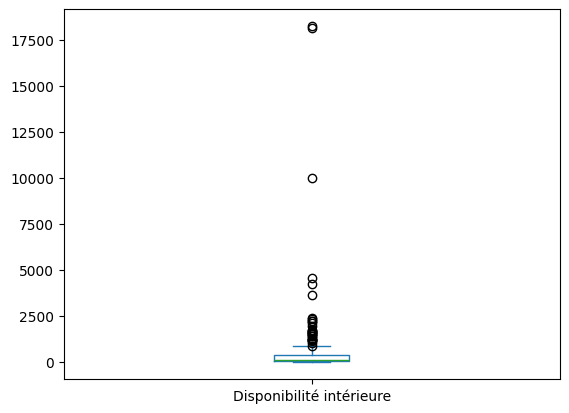

In [8]:
df_chicken_country["Disponibilité intérieure"].plot(kind="box")
plt.show()

Basés sur les observations précédentes, 5000 semble être un point de bascule entre des valeurs assez regroupées et des valeurs qui sont de plus en plus éloignées les unes des autres.

In [9]:
mask_food_availibilty = df_chicken_country["Disponibilité intérieure"] > FOOD_AVAILABILITY_THRESHOLD

In [10]:
np.sum(mask_food_availibilty)

np.int64(3)

In [11]:
countries_to_exclude = df_chicken_country[mask_food_availibilty]["Pays"].tolist()

In [12]:
mask_exclude_outliers = df_chicken_country["Pays"].isin(countries_to_exclude)
df_chicken_country_no_outliers = df_chicken_country[~mask_exclude_outliers]

Ce dataset, séparé des valeurs trop extrêmes, est prêt dans le cadre d'un processus de standardisation normale.

# **Préparation et standardisation des données**

In [13]:
df_chicken_country_normalised_srt = df_chicken_country_no_outliers.sort_values(
    "Disponibilité intérieure",
    ascending=False)
df_chicken_country_normalised_srt

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
54,Fédération de Russie,145530082,104.0,10.44,6.55,30.98,4556.0,226.0,115.0,4509.0,4444.0,0.0,54.0,0.049616,4555.0,0.000000
104,Mexique,124777324,123.0,9.26,9.27,32.52,4219.0,972.0,9.0,4058.0,3249.0,161.0,0.0,0.239941,4212.0,0.049554
72,Inde,1338676785,7.0,0.75,0.47,2.22,3661.0,0.0,4.0,2965.0,3545.0,695.0,0.0,0.000000,3541.0,0.196051
81,Japon,127502725,67.0,7.24,3.95,18.50,2415.0,1069.0,10.0,2359.0,2215.0,56.0,0.0,0.332194,3274.0,0.025282
73,Indonésie,264650963,25.0,2.42,1.61,7.19,2323.0,1.0,0.0,1904.0,2301.0,113.0,306.0,0.000457,2302.0,0.049109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Îles Salomon,636039,18.0,1.51,1.31,4.45,3.0,6.0,0.0,3.0,0.0,0.0,0.0,1.000000,6.0,0.000000
86,Kiribati,114158,63.0,6.65,3.81,17.98,2.0,1.0,0.0,2.0,1.0,0.0,0.0,0.500000,2.0,0.000000
143,Sao Tomé-et-Principe,207089,33.0,3.21,2.10,9.47,2.0,2.0,0.0,2.0,1.0,0.0,0.0,0.666667,3.0,0.000000
132,République démocratique populaire lao,6953035,41.0,3.59,2.81,10.91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000


La standardisation des données constitue une étape essentielle afin de mettre l'ensemble des variables sur une même échelle et d’éviter que des différences d'ordre de grandeur n'influencent de manière disproportionnée le processus de création des clusters.

Afin de pouvoir tester deux méthodes de création des clusters, je vais utiliser deux méthodes:
- **robuste:** qui permet de limiter l'influence des valeurs jugées extrêmes en utilisant la médiane et l'écart interquartile
- **normale:** sensible aux valeurs extrêmes car utilisant la moyenne et la déviation standard. C'est pourquoi, dans ce cas, certaines valeurs jugées trop importantes par rapport au reste ont été exclus (Brésil, Chine, USA par exemple).

Pour rentre pertinent et interprétable les clusters dans lesquels seront regroupés les différents pays, les données doivent être mis à la même échelle à travers le processus de standardisation.
Cependant la methode de standardisation peut varier en fonction de la présence ou non de valeurs jugées trop distantes par rapport au reste des données (outliers)
Ici deux méthodes vont être appliquées:
- la méthode robuste qui permet de limiter l'influence de ces données "outliers"
- la méthode standard beaucoup plus sensible à l'influence de ces outliers qui nécessite un traitement supplémentaire à savoir l'exclusion de ces valeurs dites "outliers". Cela va être notamment le cas du Brésil, de la Chine ou des Etats-Unis qui ne seront donc via cette méthode pas visées par cette étude.


Pour éviter d'exclure des marchés potentiels, les deux méthodes seront donc évaluées afin de savoir si les résultats produits diffèrent ou convergent.

In [14]:
from sklearn.preprocessing import RobustScaler, StandardScaler

## **Standardisation robuste**

In [15]:
# We drop the country to only have numerical values
df_chicken_no_country = df_chicken_country.drop("Pays", axis=1)

In [16]:
# we standardize all the values to put all of its on the same scale
rs = RobustScaler()

robust_scaled_criterias = rs.fit_transform(df_chicken_no_country)

In [17]:
df_robust_scaled_criterias = pd.DataFrame(
    data = robust_scaled_criterias,
    columns=df_chicken_no_country.columns
)
# Add the country feature from the original dataframe
df_robust_scaled_criterias["Pays"] = df_chicken_country["Pays"]

In [18]:
df_robust_scaled_criterias = df_robust_scaled_criterias[["Pays"] +
 [col for col in df_robust_scaled_criterias.columns if col != "Pays"]]

In [19]:
df_robust_scaled_criterias

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
0,Afghanistan,0.973373,-0.706587,-0.727439,-0.664720,-0.701769,-0.123494,0.169381,0.000000,-0.121073,-0.106219,1.0,0.0,0.390781,-0.132730,1.732309
1,Afrique du Sud,1.733109,0.946108,0.927439,1.071533,0.745842,6.084337,6.488599,5.250000,5.947893,4.475192,41.5,0.0,0.009579,6.084465,1.207524
2,Albanie,-0.252113,0.251497,-0.029878,0.526521,-0.073313,-0.153614,0.286645,0.000000,-0.145594,-0.148148,0.0,0.0,0.693066,-0.150830,0.000000
3,Algérie,1.160177,-0.502994,-0.553049,-0.436983,-0.496239,0.539157,-0.182410,0.000000,0.519540,0.584207,6.5,0.0,-0.330423,0.530920,1.146474
4,Allemagne,2.673852,0.083832,0.177439,0.080779,0.058481,4.942771,10.762215,53.833333,4.642146,4.047519,0.0,167.0,0.342384,4.853695,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,Venezuela (République bolivarienne du),0.720528,0.083832,0.088415,0.125547,0.092806,1.590361,0.117264,0.000000,1.537165,1.492662,15.0,0.0,-0.282628,1.580694,1.212616
168,Viet Nam,3.111870,-0.191617,-0.304268,-0.067153,-0.244094,3.337349,3.583062,0.083333,3.284291,2.381551,19.5,0.0,0.004515,3.339367,1.030328
169,Yémen,0.663029,-0.407186,-0.422561,-0.368856,-0.405128,0.445783,0.807818,0.000000,0.436782,0.285115,4.0,0.0,0.113869,0.437406,1.154873
170,Zambie,0.260259,-0.634731,-0.653049,-0.588808,-0.621676,-0.114458,-0.052117,0.083333,-0.111877,-0.047519,1.0,0.0,-0.053818,-0.123680,0.989891


## **Standardisation normale**

In [20]:
df_chicken_no_country_no_outliers = df_chicken_country_no_outliers.drop("Pays", axis=1)

In [21]:
scaler = StandardScaler()
normal_scaled_criterias = scaler.fit_transform(df_chicken_no_country_no_outliers)

Retransformer les valeurs standardisées sous forme de liste en dataframe pour avoir les features et les pays correspondants.

In [22]:
df_normal_scaled_criterias = pd.DataFrame(
    data=normal_scaled_criterias,
    columns=df_chicken_no_country_no_outliers.columns)

# Add the country to the feature have a new dataframe with the standardized values
df_normal_scaled_criterias["Pays"] = df_chicken_country_no_outliers["Pays"]

In [23]:
# Pays at the first position to be identified easier
df_normal_scaled_criterias = df_normal_scaled_criterias[["Pays"] +
 [col for col in df_normal_scaled_criterias.columns if col != "Pays"]]

In [24]:
df_normal_scaled_criterias

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
0,Afghanistan,0.039314,-1.152228,-1.176127,-1.094267,-1.179868,-0.476907,-0.312115,-0.309145,-0.474313,-0.503425,-0.185496,-0.221335,0.228962,-0.484401,1.793646
1,Afrique du Sud,0.230667,1.185100,1.289296,1.099565,1.015886,2.252981,2.314159,0.042733,2.319812,1.718828,1.124074,-0.221335,-0.353441,2.187943,1.083232
2,Albanie,-0.269346,0.202745,-0.136906,0.410918,-0.226618,-0.490152,-0.263380,-0.309145,-0.485603,-0.523763,-0.217831,-0.221335,0.690795,-0.492180,-0.551425
3,Algérie,0.086363,-0.864296,-0.916321,-0.806511,-0.868117,-0.185507,-0.458320,-0.309145,-0.179378,-0.168528,-0.007653,-0.221335,-0.872898,-0.199143,1.000586
4,Allemagne,0.467609,-0.034375,0.171953,-0.152297,-0.026712,1.750978,4.090279,3.298998,1.718652,1.511382,-0.217831,5.301855,0.155020,1.658920,-0.551425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,Ukraine,-0.024370,-0.034375,0.039325,-0.095729,0.025354,0.276759,-0.333775,-0.309145,0.289132,0.272127,0.267195,-0.221335,-0.799876,0.252082,1.090125
165,Uruguay,0.577932,-0.423930,-0.545691,-0.339215,-0.485660,1.044996,1.106614,-0.303559,1.093501,0.703290,0.412702,-0.221335,-0.361178,1.008015,0.843356
166,Vanuatu,-0.038852,-0.728799,-0.721922,-0.720430,-0.729919,-0.226568,-0.046780,-0.309145,-0.217479,-0.313605,-0.088491,-0.221335,-0.194105,-0.239339,1.011956
167,Venezuela (République bolivarienne du),-0.140297,-1.050605,-1.065301,-0.998349,-1.058382,-0.472933,-0.404170,-0.303559,-0.470080,-0.474952,-0.185496,-0.221335,-0.450298,-0.480511,0.788616


# **Réduction des données via l'ACP**

Objectif : Visualiser le nombre de composants nécessaire pour capturer le maximum de variance (>= 80%).

In [25]:
# See on a barplot how many component I will need
from sklearn.decomposition import PCA

pca = PCA()

### **Standardisation robuste**

In [26]:
cumsum_var_robust, features_robust = pca_components(robust_scaled_criterias, pca)

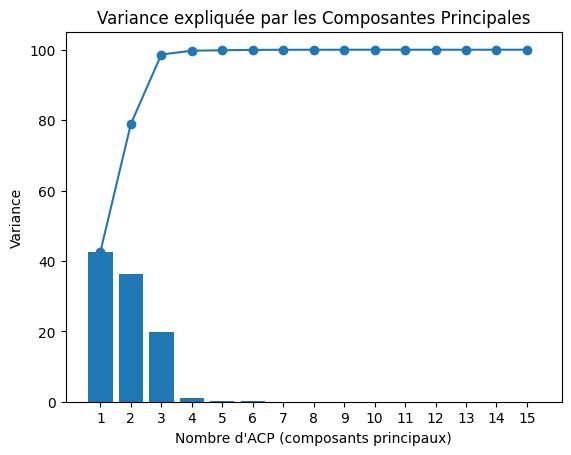

In [27]:
plot_pca_components(features_robust, cumsum_var_robust, pca)

In [28]:
cumsum_pca_robust = list(zip(cumsum_var_robust, features_robust))

In [29]:
component_robust = max(
    (x for x in cumsum_pca_robust if x[0] <= 0.8), key=lambda x: x[0])[1]
component_robust

2

In [30]:
n_components_robust = N_COMPONENTS_ROBUST_SCALED
print(f"Nombre de composants: {n_components_robust}")

Nombre de composants: 2


Les deux premiers composants capture **quasiment 80% de la variance**, ce qui est suffisant pour construire un cluster de qualité.

### **Standardisation normale**

La standardisation classique utilise la moyenne et la déviation standard le rendant beaucoup plus sensible aux valeurs extrêmes dites "outliers".

In [31]:
cumsum_var_normal, features_normal = pca_components(normal_scaled_criterias, pca)

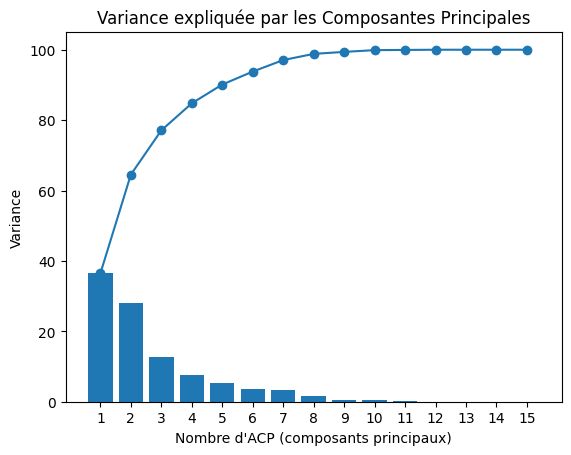

In [32]:
plot_pca_components(features_normal, cumsum_var_normal, pca)

In [33]:
cumsum_pca_normal = list(zip(cumsum_var_normal, features_normal))

In [34]:
component_normal = max(
    (x for x in cumsum_pca_normal if x[0] <= 0.8), key=lambda x: x[0])[1]
component_normal

3

# **Analyse des corrélations**

**Objectif**
L'objectif est de comprendre les relations linéaires, positives ou négatives, entre les composantes principales et les critères nécessaires à l'étude.

Afin de visualiser l'ensemble de ces corrélations, nous utiliserons le cercle des corrélations ainsi qu'une heatmap de corrélations. Ces deux outils, bien que différents dans leur approche, sont complémentaires dans le cadre d'une analyse des relations linéaires.

Le cercle des corrélations représente les variables sous forme de vecteurs projetés dans un plan défini par deux composantes principales. La force et la nature des relations sont déterminées par l'orientation des vecteurs, leur longueur et l'angle qu'ils forment entre eux.

La heatmap de corrélations, quant à elle, met en évidence l'intensité et le sens des relations linéaires entre les variables à l'aide d'une échelle de couleurs. Les coefficients de corrélation varient généralement entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite).

Toutefois, l'analyse des corrélations n'existe qu'avec la standardisation normale comme la standardisation robuste élimine toute relation linéaire entre les attributs.

La section suivante permet d'associer les composants (données réduits lors de l'étape précédente) et les différentes métriques de l'étude.
Cela permet notamment de correctement interpréter les graphiques et comprendre les facteurs qui expliquent les différences observées.

## **Standardisation normale**

In [35]:
pca_normal = PCA(n_components=n_components_normal)

In [36]:
criterias_normal_transformed_pca = pca_normal.fit_transform(normal_scaled_criterias)

In [37]:
# Calculate the loadings (correlation between original variables and principal components)
# The loadings are the eigenvectors scaled by the square root of the eigenvalues
correlations = pca_normal.components_.T * np.sqrt(pca_normal.explained_variance_)

In [38]:
# Iterate authomatically on the right number of indexes in the array
columns_pca_normal = [f'PC{i+1}' for i in range(correlations.shape[1])]

### **Heatmap des corrélations**

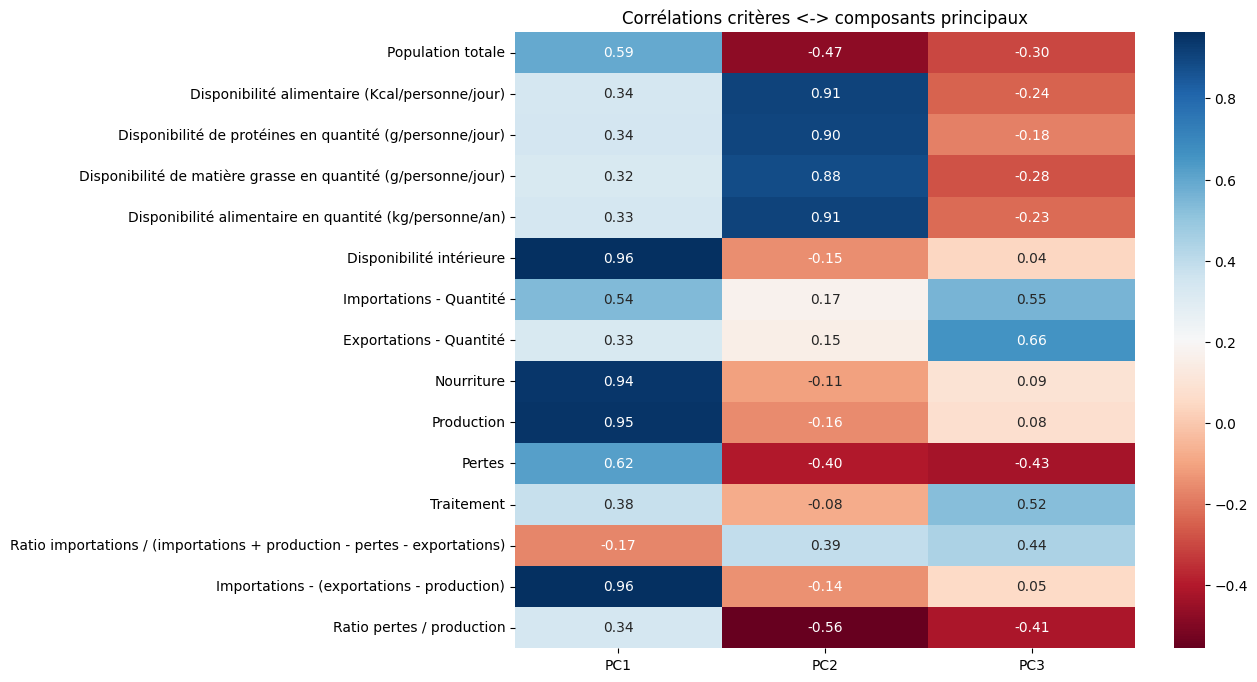

In [39]:
# Create a DataFrame from the loadings for better visualization
loadings_df = pd.DataFrame(correlations, index=df_chicken_no_country_no_outliers.columns, columns=columns_pca_normal)

# heatmap to see the correlations between original variables and principal components
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, cmap='RdBu', annot=True, fmt=".2f")
plt.title(PLOT_TITLE_CORR_PCA_CRITERIONS)
plt.show()

Les corrélations les plus pertinentes sont principalement sur les deux premiers composants. Les autres n'influencent que très peu. C'est pourquoi pour la suite, l'idée de garder les 4 composants semble pertinente pour capturer une variance plus importante mais non pertinente pour la visualisation.

### **Cercle des corrélations**

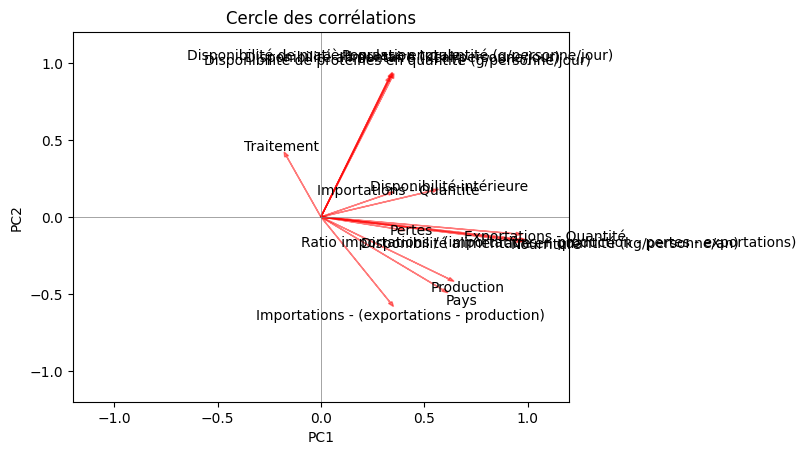

In [40]:
# Plot the arrows representing the original variables
correlations = correlations[:, 0:2]
for i, (x, y) in enumerate(correlations):
    plt.arrow(0, 0, x, y, color='r', alpha=0.5, width=0.0005, head_width=0.02)
    plt.text(x * 1.15, y * 1.15, df_chicken_country_no_outliers.columns[i], color='black', ha='center', va='center')

# Set plot limits and labels
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cercle des corrélations')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.show()

### **Association critères <-> APC**

Dans cette section, je ne vais prendre que les correlations qui sont supérieurs dans leur valeur absolue à 0.5

In [41]:
strong_correlations = loadings_df[loadings_df.abs()>0.5]
strong_correlations

,PC1,PC2,PC3
Population totale,0.590677,NaN,NaN
Disponibilité alimentaire (Kcal/personne/jour),NaN,0.907384,NaN
Disponibilité de protéines en quantité (g/personne/jour),NaN,0.902521,NaN
Disponibilité de matière grasse en quantité (g/personne/jour),NaN,0.883412,NaN
Disponibilité alimentaire en quantité (kg/personne/an),NaN,0.909546,NaN
Disponibilité intérieure,0.963143,NaN,NaN
Importations - Quantité,0.540270,NaN,0.554848
Exportations - Quantité,NaN,NaN,0.655730
Nourriture,0.944280,NaN,NaN
Production,0.947934,NaN,NaN


In [42]:
best_correlations = pd.DataFrame({
    "Best PC": strong_correlations.abs().idxmax(axis=1),
     "Best value": strong_correlations.abs().max(axis=1)
    }).reset_index()
best_correlations.rename(columns={'index': 'Criterion'}, inplace=True)

/tmp/ipython-input-3966419897.py:2: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "Best PC": strong_correlations.abs().idxmax(axis=1),


In [43]:
best_correlations

,Criterion,Best PC,Best value
0,Population totale,PC1,0.590677
1,Disponibilité alimentaire (Kcal/personne/jour),PC2,0.907384
2,Disponibilité de protéines en quantité (g/pers...,PC2,0.902521
3,Disponibilité de matière grasse en quantité (g...,PC2,0.883412
4,Disponibilité alimentaire en quantité (kg/pers...,PC2,0.909546
5,Disponibilité intérieure,PC1,0.963143
6,Importations - Quantité,PC3,0.554848
7,Exportations - Quantité,PC3,0.655730
8,Nourriture,PC1,0.944280
9,Production,PC1,0.947934


In [44]:
for pc, group in best_correlations.groupby("Best PC"):
  print(f"{pc}:")
  for _, row in group.iterrows():
    print(f'{row["Criterion"]} - {row["Best value"]}')
  print("\n")

PC1:
Population totale - 0.5906769652596946
Disponibilité intérieure - 0.9631431524022878
Nourriture - 0.9442798812275102
Production - 0.9479335581358236
Pertes - 0.6192959962079014
Importations - (exportations - production) - 0.9600552414343716


PC2:
Disponibilité alimentaire (Kcal/personne/jour) - 0.9073843748277907
Disponibilité de protéines en quantité (g/personne/jour) - 0.9025205826039363
Disponibilité de matière grasse en quantité (g/personne/jour) - 0.8834116382338553
Disponibilité alimentaire en quantité (kg/personne/an) - 0.9095461103395915
Ratio pertes / production - 0.5558074013711035


PC3:
Importations - Quantité - 0.5548477436258162
Exportations - Quantité - 0.655730308899683
Traitement - 0.5241681130388043




Après l’analyse de la **heatmap** et du **cercle de corrélation**, plusieurs critères dominants apparaissent selon les composantes principales :

- **Premier composant (PC1)** :  
  Il est caractérisé par des **corrélations positives** avec la **disponibilité intérieure**, la **nourriture**, la **production** et les **exportations**, par des pertes plus importantes et par une **corrélation positive** avec les importations nettes

- **Second composant (PC2)** :  
  Il est principalement associé à la **disponibilité alimentaire par habitant**, exprimée en **kilogrammes, grammes et kilocalories**.

Les **pays dominés par le premier composant (PC1)** se distinguent par une **production agricole importante**, une **présence accrue sur les marchés internationaux**, notamment à travers les exportations, ainsi qu’une **politique agricole globalement plus performante**, impliquant une **moindre dépendance aux importations**.

À l’inverse, les **pays dominés par le second composant (PC2)** présentent une **meilleure disponibilité et répartition alimentaire par habitant**, traduisant un niveau de consommation individuelle plus élevé.


## **Standardisation robuste**

In [45]:
pca_robust = PCA(n_components=n_components_robust)

In [46]:
criterias_robust_transformed_pca = pca_robust.fit_transform(robust_scaled_criterias)

In [47]:
correlations_robust = pca_robust.components_.T * np.sqrt(pca_robust.explained_variance_)

In [48]:
columns_pca_robust = [f"PC{i+1}" for i in range(criterias_robust_transformed_pca.shape[1])]

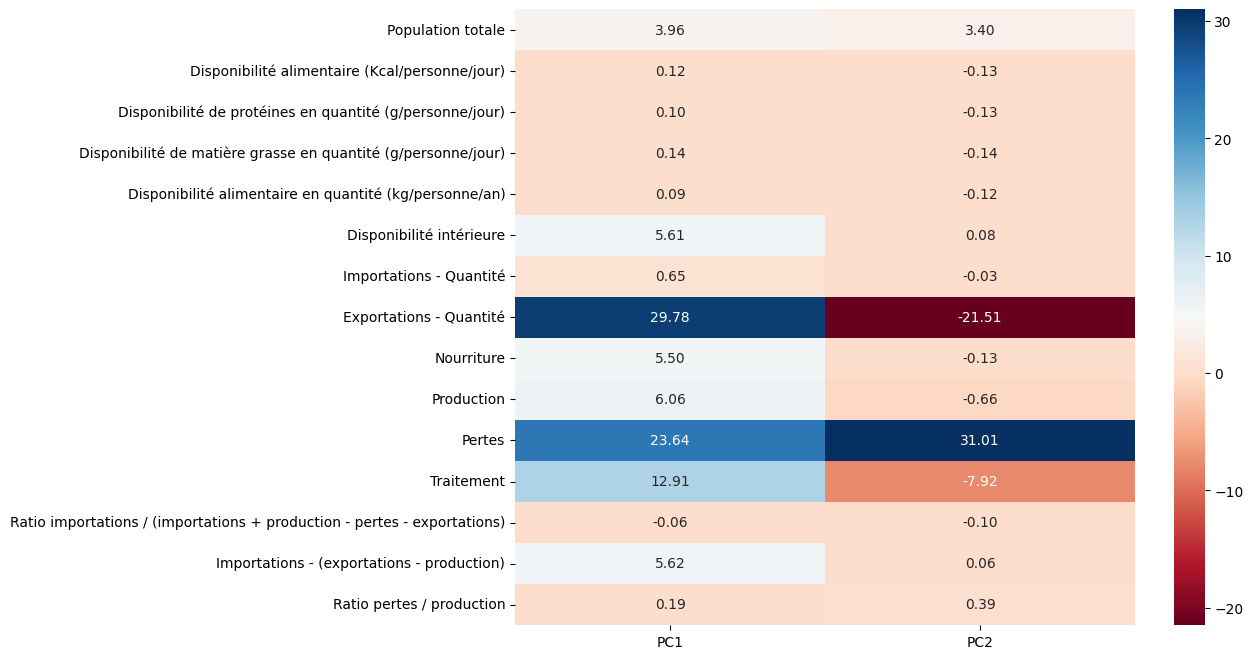

In [49]:
# Create a DataFrame from the loadings for better visualization
loadings_df = pd.DataFrame(correlations_robust, index=df_chicken_no_country.columns, columns=columns_pca_robust)

# heatmap to see the correlations between original variables and principal components
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, cmap='RdBu', annot=True, fmt=".2f")
plt.title("")
plt.show()

Ici toutes les mesures ne sont plus vraiment des coefficients linéaires car non normés entre -1 et +1 à cause de la manière dont cette technique réduit l'impact des valeurs extrêmes. Il s'agit plus d'associations linéaires.

Sans certains pays possédant des valeurs très élévés, la majorité des pays se retrouvent très concentrés.

# **Projection des individus**

**Objectif:** Visualisation à l'aide d'un scatter plot, l'existence éventuelle de structures ou de similarités entre les différents pays, en les projetant sur les deux première composantes principales (PC1 et PC2). Il permet également de déterminer les pays qui peuvent sortir du lot et appelés "outliers"

Pour rappel :

Les **pays dominés par le premier composant (PC1)** se distinguent par une **production agricole importante**, une **présence accrue sur les marchés internationaux**, notamment à travers les exportations, ainsi qu’une **politique agricole globalement plus performante**, impliquant une **moindre dépendance aux importations**.

À l’inverse, les **pays dominés par le second composant (PC2)** présentent une **meilleure disponibilité et répartition alimentaire par habitant**, traduisant un niveau de consommation individuelle plus élevé.

## **Standardisation robuste**

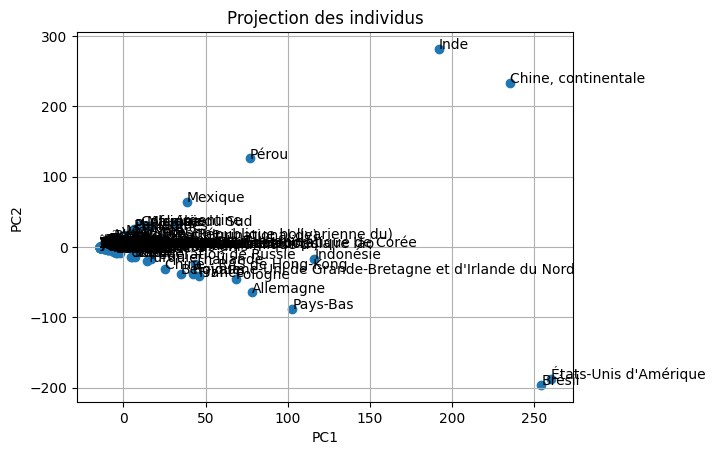

In [50]:
# We take the first 2 components as they have more variance difference
# Individual projections
plt.scatter(criterias_robust_transformed_pca[:, 0],
            criterias_robust_transformed_pca[:, 1])

for i, txt in enumerate(df_chicken_country['Pays']):
  plt.text(criterias_robust_transformed_pca[i, 0],
            criterias_robust_transformed_pca[i, 1],
            txt)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.title(PLOT_TITLE_PROJECTION)
plt.show()

Sans surprise, certains pays comme la Chine, les Etats-Unis, l'Inde ou le Brésil sortent du lot, car ils possèdent des valeurs plus importantes en raison d'une population plus importante et d'un territoire beaucoup plus vaste, ce qui détermine des chiffres plus importants.

## **Standardisation normale**

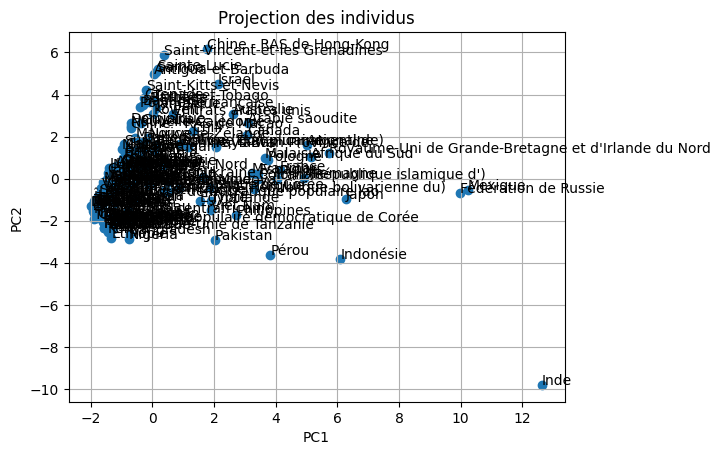

In [51]:
# Building the scatter plot
plt.scatter(
    criterias_normal_transformed_pca[:, 0],
    criterias_normal_transformed_pca[:, 1]
)

for i, txt in enumerate(df_chicken_country_no_outliers["Pays"]):
  plt.text(
      criterias_normal_transformed_pca[i, 0],
      criterias_normal_transformed_pca[i, 1],
      txt
  )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.title('Projection des individus')

plt.show()

Certains pays comme l'Indonésie, la Russie ou la Grande Bretagne sont des pays plus inflencés par le premier composant et donc plus perfomants au niveau agricole tandis que d'autres comme Hong-Kong, les îles de Sainte Lucie ou les îles grenadines semblent être plus associées au deuxième composant soit une meilleure répartition alimentaire entre les habitants.

# **Intégration des APC aux dataframes de base**

## **Standardisation robuste**

In [52]:
reshape_dataframe(criterias_robust_transformed_pca,
                        [df_robust_scaled_criterias, df_chicken_country])

In [53]:
df_chicken_country

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2
0,Afghanistan,36296113,5.0,0.54,0.33,1.53,57.0,29.0,0.0,55.0,28.0,2.0,0.0,0.527273,57.0,0.071429,-13.585043,0.277851
1,Afrique du Sud,57009756,143.0,14.11,9.25,35.69,2118.0,514.0,63.0,2035.0,1667.0,83.0,0.0,0.252580,2118.0,0.049790,16.284038,29.757523
2,Albanie,2884169,85.0,6.26,6.45,16.36,47.0,38.0,0.0,47.0,13.0,0.0,0.0,0.745098,51.0,0.000000,-14.276666,-0.659959
3,Algérie,41389189,22.0,1.97,1.50,6.38,277.0,2.0,0.0,264.0,275.0,13.0,0.0,0.007576,277.0,0.047273,-10.110098,4.681093
4,Allemagne,82658409,71.0,7.96,4.16,19.47,1739.0,842.0,646.0,1609.0,1514.0,0.0,167.0,0.492398,1710.0,0.000000,78.389985,-64.524249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,Venezuela (République bolivarienne du),29402484,71.0,7.23,4.39,20.28,626.0,25.0,0.0,596.0,600.0,30.0,0.0,0.042017,625.0,0.050000,-4.801980,11.427298
168,Viet Nam,94600648,48.0,4.01,3.40,12.33,1206.0,291.0,1.0,1166.0,918.0,39.0,0.0,0.248931,1208.0,0.042484,-1.103674,15.179120
169,Yémen,27834819,30.0,3.04,1.85,8.53,246.0,78.0,0.0,237.0,168.0,8.0,0.0,0.327731,246.0,0.047619,-11.629726,2.637225
170,Zambie,16853599,11.0,1.15,0.72,3.42,60.0,12.0,1.0,58.0,49.0,2.0,0.0,0.206897,60.0,0.040816,-13.586412,0.160835


In [54]:
df_robust_scaled_criterias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 18 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Pays                                                                      172 non-null    object 
 1   Population totale                                                         172 non-null    float64
 2   Disponibilité alimentaire (Kcal/personne/jour)                            172 non-null    float64
 3   Disponibilité de protéines en quantité (g/personne/jour)                  172 non-null    float64
 4   Disponibilité de matière grasse en quantité (g/personne/jour)             172 non-null    float64
 5   Disponibilité alimentaire en quantité (kg/personne/an)                    172 non-null    float64
 6   Disponibilité intérieure                                          

In [55]:
df_chicken_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 18 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Pays                                                                      172 non-null    object 
 1   Population totale                                                         172 non-null    int64  
 2   Disponibilité alimentaire (Kcal/personne/jour)                            172 non-null    float64
 3   Disponibilité de protéines en quantité (g/personne/jour)                  172 non-null    float64
 4   Disponibilité de matière grasse en quantité (g/personne/jour)             172 non-null    float64
 5   Disponibilité alimentaire en quantité (kg/personne/an)                    172 non-null    float64
 6   Disponibilité intérieure                                          

## **Standardisation normale**

In [56]:
reshape_dataframe(criterias_normal_transformed_pca,
                        [df_normal_scaled_criterias, df_chicken_country_no_outliers])

/tmp/ipython-input-1767515632.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"PC{i+1}"] = criterias[:, i]
/tmp/ipython-input-1767515632.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"PC{i+1}"] = criterias[:, i]
/tmp/ipython-input-1767515632.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [57]:
df_normal_scaled_criterias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 19 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Pays                                                                      166 non-null    object 
 1   Population totale                                                         169 non-null    float64
 2   Disponibilité alimentaire (Kcal/personne/jour)                            169 non-null    float64
 3   Disponibilité de protéines en quantité (g/personne/jour)                  169 non-null    float64
 4   Disponibilité de matière grasse en quantité (g/personne/jour)             169 non-null    float64
 5   Disponibilité alimentaire en quantité (kg/personne/an)                    169 non-null    float64
 6   Disponibilité intérieure                                          

In [58]:
df_chicken_country_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 171
Data columns (total 19 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Pays                                                                      169 non-null    object 
 1   Population totale                                                         169 non-null    int64  
 2   Disponibilité alimentaire (Kcal/personne/jour)                            169 non-null    float64
 3   Disponibilité de protéines en quantité (g/personne/jour)                  169 non-null    float64
 4   Disponibilité de matière grasse en quantité (g/personne/jour)             169 non-null    float64
 5   Disponibilité alimentaire en quantité (kg/personne/an)                    169 non-null    float64
 6   Disponibilité intérieure                                               

# **Classification ascendante hiérarchique**

**Objectif :**  
Afin de compléter l’analyse en composantes principales, nous avons recours à une **classification hiérarchique** représentée par un **dendrogramme**, dont l’objectif est d’identifier des **groupes de pays présentant des profils similaires**, en s’appuyant sur leurs caractéristiques communes.

La détermination de ces clusters repose sur **trois étapes principales** :

1. **Regroupement des données**, en mesurant la similarité ou la distance entre les pays.  
2. **Construction de l’arbre hiérarchique (dendrogramme)** afin de visualiser la formation progressive des groupes.  
3. **Identification et attribution du numéro de cluster** à chaque observation, correspondant ici à chaque pays après détermination du seuil (t).

In [59]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## **Standardisation robuste**

### **1 - regoupement hiérarchique**

Utilisation de la dataframe standardisée avec les APC déjà inclus

In [60]:
# Step 1 : perform hierarchical clustering
Z_robust = linkage(df_robust_scaled_criterias[columns_pca_robust], method="complete")

### **2 - Création du dendogramme**

Determiner le nombre de clusters en fonction du score produit par l'évaluation du dendograme

In [61]:
pair_scores = number_cluster_dendogram(df_robust_scaled_criterias,
                             columns_pca_robust,
                             2,
                             11,
                             Z_robust)
pair_scores

{2: np.float64(0.9040699733368835),
 3: np.float64(0.9217391111879211),
 4: np.float64(0.8734296803826269),
 5: np.float64(0.8575922145612529),
 6: np.float64(0.7699591210599459),
 7: np.float64(0.8103883336177785),
 8: np.float64(0.8105915571929277),
 9: np.float64(0.802868585223413),
 10: np.float64(0.8004284756623362)}

In [62]:
# Take the max score to retrieve the label associated
max_pair_score = max(pair_scores, key=pair_scores.get)
print(f"Number of clusters: {max_pair_score}")

Number of clusters: 3


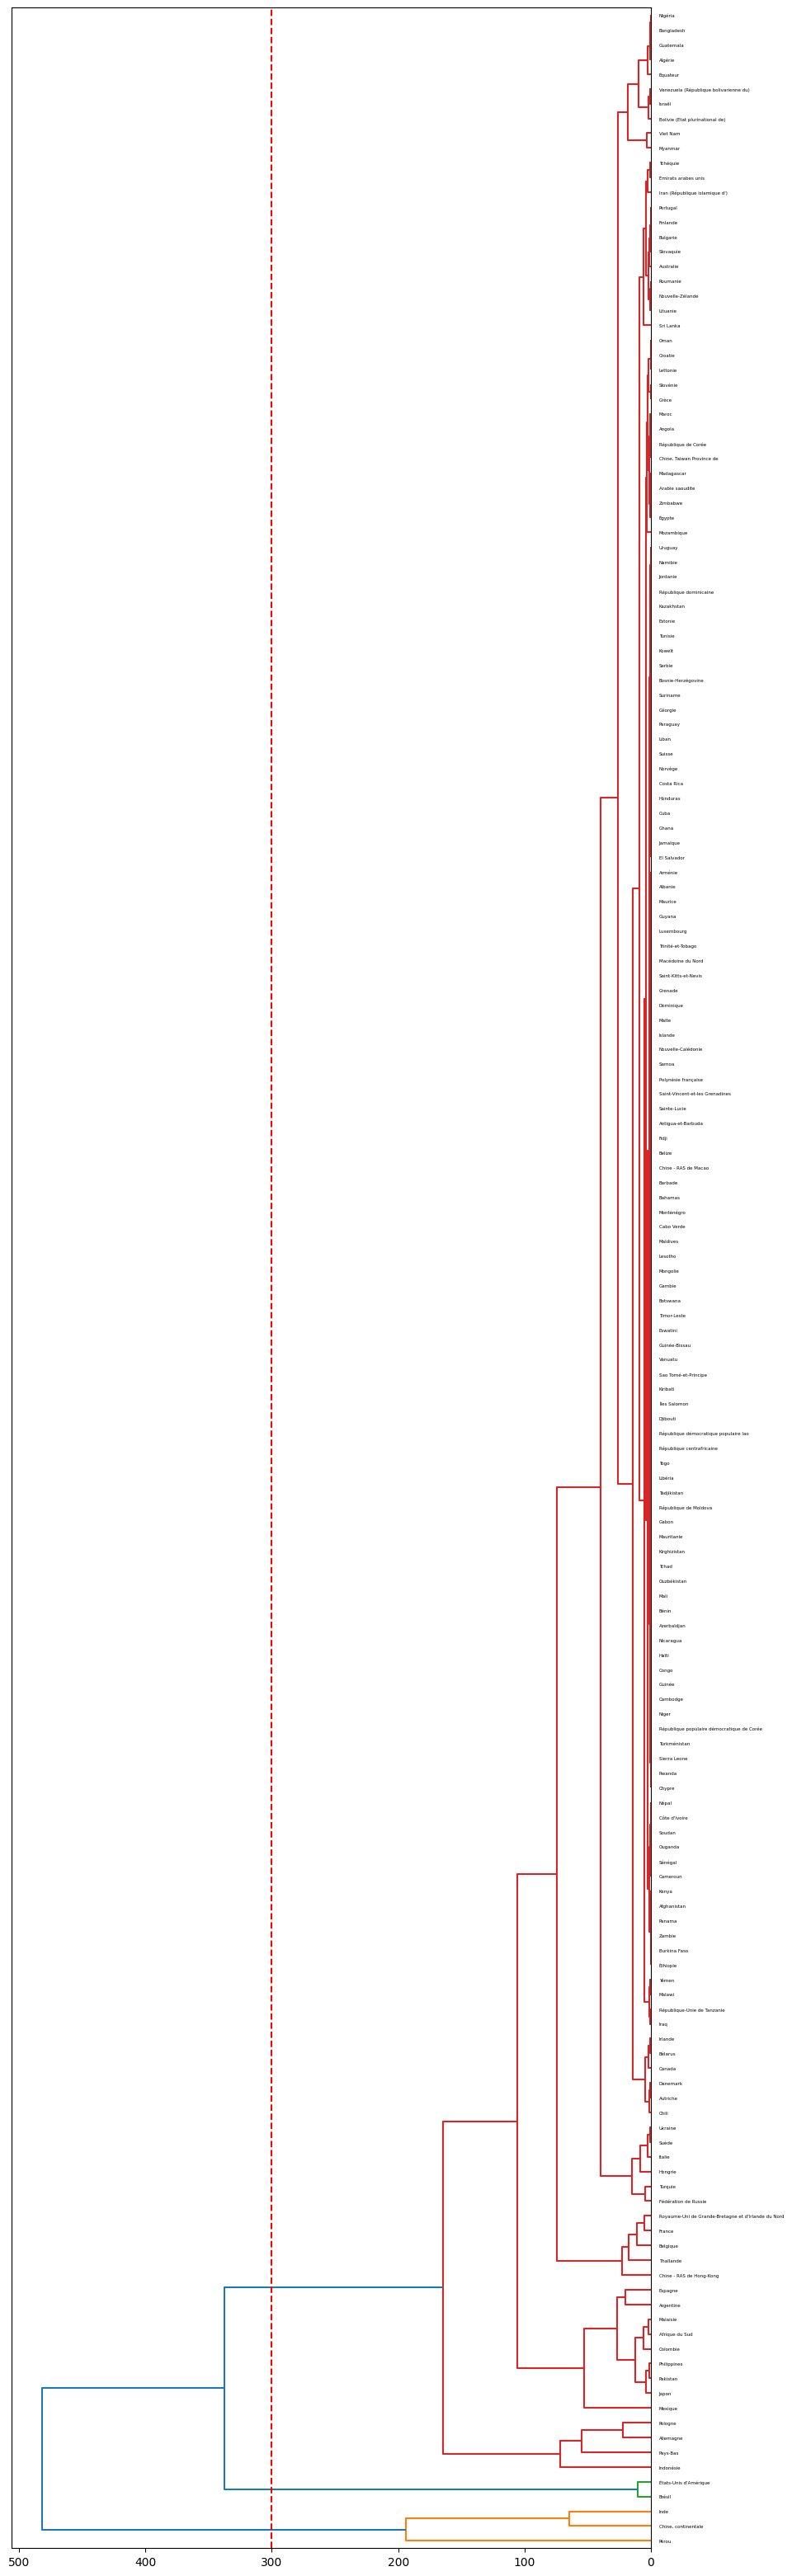

In [63]:
plot_dendogram(
    df_robust_scaled_criterias,
    "Pays", Z_robust, T_ROBUST_HIERARCHICAL, figsize=(10,40)
)

### **3-Détermination du nombre de clusters**

In [64]:
# Step 3 : Cut the tree at the chosen number of clusters
clusters_robust = fcluster(Z_robust,
                    t=T_ROBUST_HIERARCHICAL,
                    criterion='distance')

df_robust_scaled_criterias['Hierarchical_cluster'] = clusters_robust

In [65]:
df_robust_scaled_criterias.head()

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster
0,Afghanistan,0.973373,-0.706587,-0.727439,-0.664720,-0.701769,-0.123494,0.169381,0.000000,-0.121073,-0.106219,1.0,0.0,0.390781,-0.132730,1.732309,-13.585043,0.277851,3
1,Afrique du Sud,1.733109,0.946108,0.927439,1.071533,0.745842,6.084337,6.488599,5.250000,5.947893,4.475192,41.5,0.0,0.009579,6.084465,1.207524,16.284038,29.757523,3
2,Albanie,-0.252113,0.251497,-0.029878,0.526521,-0.073313,-0.153614,0.286645,0.000000,-0.145594,-0.148148,0.0,0.0,0.693066,-0.150830,0.000000,-14.276666,-0.659959,3
3,Algérie,1.160177,-0.502994,-0.553049,-0.436983,-0.496239,0.539157,-0.182410,0.000000,0.519540,0.584207,6.5,0.0,-0.330423,0.530920,1.146474,-10.110098,4.681093,3
4,Allemagne,2.673852,0.083832,0.177439,0.080779,0.058481,4.942771,10.762215,53.833333,4.642146,4.047519,0.0,167.0,0.342384,4.853695,0.000000,78.389985,-64.524249,3


In [66]:
n_clusters_hierarchical_robust = df_robust_scaled_criterias['Hierarchical_cluster'].nunique()
print(f"Number of clusters: {n_clusters_hierarchical_robust}")

Number of clusters: 3


Grâce à l'analyse du **dendrogramme** et à la détermination d'un **seuil de coupure fixé à 300**, le nombre de **clusters retenu est de 3**.  
Ce choix permet de

### **4 - Visualisation des clusters**

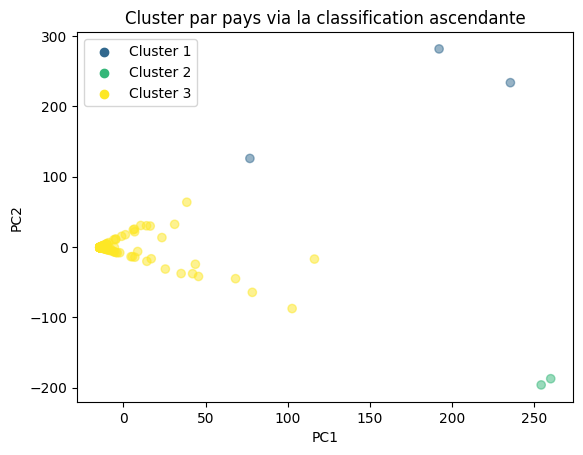

In [67]:
plot_cluster_kmeans_hierarchical(
    "Hierarchical",
    df_robust_scaled_criterias,
    ["PC1", "PC2", "Hierarchical_cluster"],
    n_clusters_hierarchical_robust,
    PLOT_TITLE_CLUSTER_ASCENDANT,
    "PC1",
    "PC2"
)

On remarque que les clusters 3, 4 et 5 ne sont composés que d'un seul pays, ce qui confirme que certains pays sont uniques et considérés comme des outliers mais pas comme des valeurs aberrantes.

## **Standardisation normale**

In [68]:
columns_pca_normal = [f"PC{i+1}" for i in range(criterias_normal_transformed_pca.shape[1])]

### **1-Regroupement hiérarchique**

In [69]:
Z_normal = linkage(df_normal_scaled_criterias[columns_pca_normal], method="complete")

### **2-Création du dendogramme**

In [70]:
pair_scores = number_cluster_dendogram(df_normal_scaled_criterias,
                             columns_pca_normal,
                             2,
                             11,
                             Z_normal)

In [71]:
pair_scores

{2: np.float64(0.7833066565066257),
 3: np.float64(0.5772157597131911),
 4: np.float64(0.5374490000184711),
 5: np.float64(0.4725651071837978),
 6: np.float64(0.46977989638295453),
 7: np.float64(0.46846721669002744),
 8: np.float64(0.478118173915898),
 9: np.float64(0.4790371116501751),
 10: np.float64(0.3819627786662372)}

In [72]:
max_pair_score = max(pair_scores, key=pair_scores.get)
print(f"Number of clusters : {max_pair_score}")

Number of clusters : 2


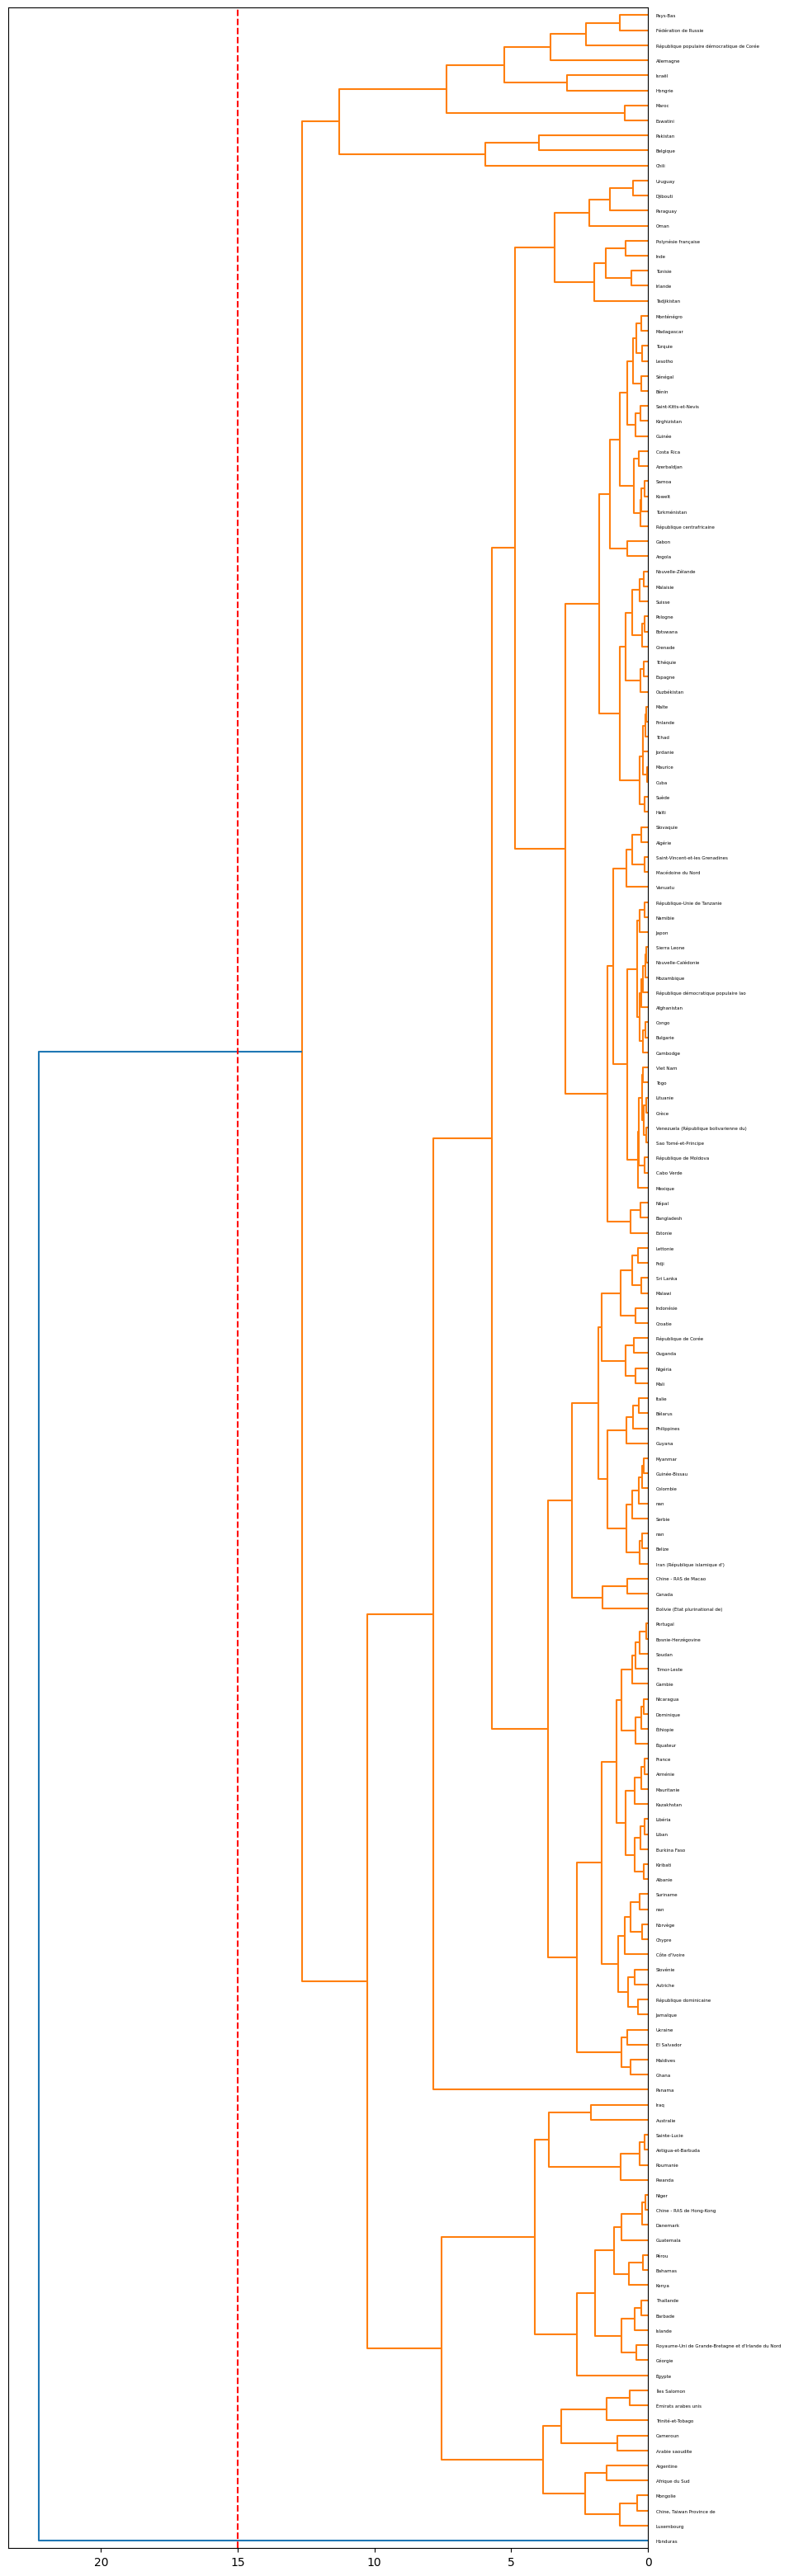

In [73]:
plot_dendogram(
    df_normal_scaled_criterias,
    "Pays", Z_normal, T_NORMAL_HIERARCHICAL, figsize=(10,40)
)

### **3-Détermination des clusters**

In [74]:
# Step 3 : Cut the tree at the chosen number of clusters
clusters_normal = fcluster(Z_normal,
                    t=T_NORMAL_HIERARCHICAL,
                    criterion='distance')

df_normal_scaled_criterias['Hierarchical_cluster'] = clusters_normal

In [75]:
n_clusters_hierarchical_normal = df_normal_scaled_criterias['Hierarchical_cluster'].nunique()
print(f"Number of clusters: {n_clusters_hierarchical_normal}")

Number of clusters: 2


### **4-Visualisation des clusters**

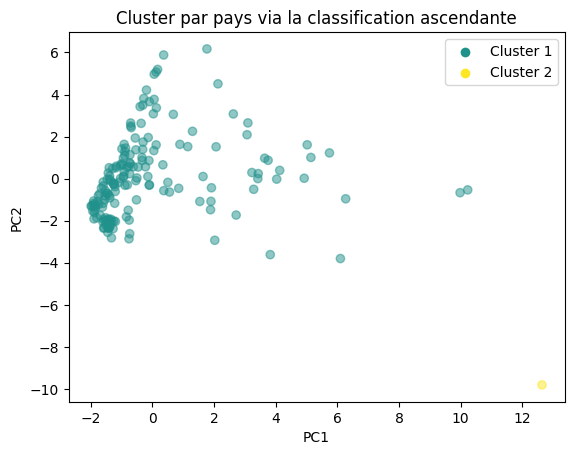

In [76]:
plot_cluster_kmeans_hierarchical(
    "Hierarchical",
    df_normal_scaled_criterias,
    ["PC1", "PC2", "Hierarchical_cluster"],
    n_clusters_hierarchical_normal,
    PLOT_TITLE_CLUSTER_ASCENDANT,
    "PC1",
    "PC2"
)

# **KMeans**

**Objectif :**  
L'algorithme de **k-means** permet de **partitionner les données en *k* clusters** en les regroupant autour de **centroïdes**, correspondant à des **centres de gravité définis par des caractéristiques communes**.  
Les centroïdes sont **suffisamment éloignés les uns des autres** afin de garantir une **séparation claire entre les clusters**.

In [77]:
# import KMean from scikit-learn
from sklearn.cluster import KMeans

## **Standardisation robuste**

### **1 - Méthode du coude: déterminer le nombre de clusters optimal**

In [78]:
k_range = range(1, K_MAX)

title_elbow_plot = PLOT_TITLE_ELBOW_METHOD
xlabel = PLOT_XLABEL_NUM_CLUSTERS
ylabel = PLOT_YLABEL_INERTIA

In [79]:
inertia = inertia_scores_kmeans(df_robust_scaled_criterias, columns_pca_robust, k_range)

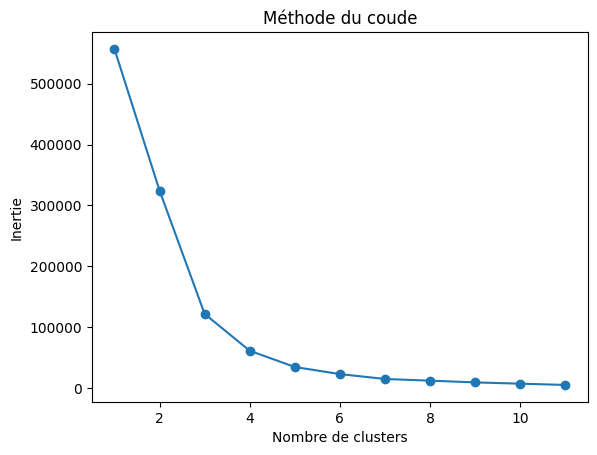

In [80]:
plot_inertia(
    k_range, inertia, title_elbow_plot, xlabel, ylabel
)

In [81]:
scores_k = number_cluster_kmeans(df_robust_scaled_criterias,
                                 columns_pca_robust, 2, 12)
scores_k

{2: np.float64(0.9001034332902826),
 3: np.float64(0.9313276218796351),
 4: np.float64(0.8461759863071481),
 5: np.float64(0.8293702553729699),
 6: np.float64(0.8128315570405161),
 7: np.float64(0.8177297727658513),
 8: np.float64(0.79758082422702),
 9: np.float64(0.7739260814331389),
 10: np.float64(0.766203109463624),
 11: np.float64(0.7641498394268694)}

In [82]:
max_cluster_robust=max(scores_k, key=scores_k.get)
max_cluster_robust

3

In [83]:
n_clusters_kmeans_robust = max_cluster_robust

Après observation du graphique, **l'inertie semble être moins importante autour de 3 et confirmé par le silouhette score**

### **2 - Visualisation des clusters et des centroides**

In [84]:
X_cluster = df_robust_scaled_criterias[columns_pca_robust]

# Use of KMeans
kmeans = KMeans(n_clusters=n_clusters_kmeans_robust, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_cluster)

df_robust_scaled_criterias['KMean_cluster'] = kmeans.labels_

In [85]:
# See the centroids for each kmean clusters
centroids = kmeans.cluster_centers_

In [86]:
n_kmean_clusters_robust = df_robust_scaled_criterias['KMean_cluster'].nunique()

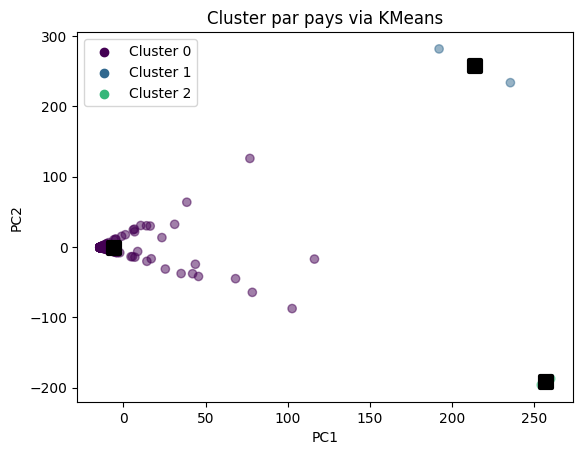

In [87]:
# Plot the cluster
plot_cluster_kmeans_hierarchical(
    "KMeans",
    df_robust_scaled_criterias,
    ["PC1", "PC2", "KMean_cluster"],
    n_kmean_clusters_robust,
    PLOT_TITLE_CLUSTER_KMEAN,
    "PC1",
    "PC2",
    centroids
)

Les clusters 1 et 2 plutôt isolés du reste et assez éloignés de leur centroide.

### **3 - Nombre et pays par cluster**

**1 - Cluster ascendant hierarchique**

In [88]:
# We recreate a dataframe with the standardized values, the countries and the KMean cluster
df_final_robust_scaled_chicken_country = pd.DataFrame(df_robust_scaled_criterias, columns=df_robust_scaled_criterias.columns)
df_final_robust_scaled_chicken_country[columns_pca_robust + ["Pays", "KMean_cluster", "Hierarchical_cluster"]] = df_robust_scaled_criterias.loc[:, columns_pca_robust + ["Pays", "KMean_cluster", "Hierarchical_cluster"]]

In [89]:
df_final_robust_scaled_chicken_country

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster,KMean_cluster
0,Afghanistan,0.973373,-0.706587,-0.727439,-0.664720,-0.701769,-0.123494,0.169381,0.000000,-0.121073,-0.106219,1.0,0.0,0.390781,-0.132730,1.732309,-13.585043,0.277851,3,0
1,Afrique du Sud,1.733109,0.946108,0.927439,1.071533,0.745842,6.084337,6.488599,5.250000,5.947893,4.475192,41.5,0.0,0.009579,6.084465,1.207524,16.284038,29.757523,3,0
2,Albanie,-0.252113,0.251497,-0.029878,0.526521,-0.073313,-0.153614,0.286645,0.000000,-0.145594,-0.148148,0.0,0.0,0.693066,-0.150830,0.000000,-14.276666,-0.659959,3,0
3,Algérie,1.160177,-0.502994,-0.553049,-0.436983,-0.496239,0.539157,-0.182410,0.000000,0.519540,0.584207,6.5,0.0,-0.330423,0.530920,1.146474,-10.110098,4.681093,3,0
4,Allemagne,2.673852,0.083832,0.177439,0.080779,0.058481,4.942771,10.762215,53.833333,4.642146,4.047519,0.0,167.0,0.342384,4.853695,0.000000,78.389985,-64.524249,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,Venezuela (République bolivarienne du),0.720528,0.083832,0.088415,0.125547,0.092806,1.590361,0.117264,0.000000,1.537165,1.492662,15.0,0.0,-0.282628,1.580694,1.212616,-4.801980,11.427298,3,0
168,Viet Nam,3.111870,-0.191617,-0.304268,-0.067153,-0.244094,3.337349,3.583062,0.083333,3.284291,2.381551,19.5,0.0,0.004515,3.339367,1.030328,-1.103674,15.179120,3,0
169,Yémen,0.663029,-0.407186,-0.422561,-0.368856,-0.405128,0.445783,0.807818,0.000000,0.436782,0.285115,4.0,0.0,0.113869,0.437406,1.154873,-11.629726,2.637225,3,0
170,Zambie,0.260259,-0.634731,-0.653049,-0.588808,-0.621676,-0.114458,-0.052117,0.083333,-0.111877,-0.047519,1.0,0.0,-0.053818,-0.123680,0.989891,-13.586412,0.160835,3,0


**2 - Cluster KMeans**

In [90]:
visualize_cluster_details(df_final_robust_scaled_chicken_country, "KMean_cluster")

 Cluster 1 - Nombre de pays : 2


,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster,KMean_cluster
33,"Chine, continentale",51.762424,-0.059880,-0.310366,0.180049,-0.244094,54.406627,5.680782,48.000000,53.405364,50.789658,321.5,1.0,-0.305030,54.331825,0.855135,235.349561,233.681900,1,1
72,Inde,48.742169,-0.682635,-0.701829,-0.637470,-0.672529,10.731928,-0.208469,0.333333,8.798467,9.724668,347.5,0.0,-0.340937,10.377074,4.754687,191.978126,281.670664,1,1




 Cluster 2 - Nombre de pays : 2


,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster,KMean_cluster
23,Brésil,7.265043,1.676647,1.118902,2.256934,1.268778,29.771084,-0.169381,351.916667,30.306513,39.510832,0.0,0.0,-0.340519,29.803922,0.0,254.075472,-196.182843,2,2
52,États-Unis d'Amérique,11.565580,1.856287,1.637195,2.157664,1.592965,54.722892,1.394137,307.666667,55.189272,61.070580,0.0,77.0,-0.331632,55.034691,0.0,259.885392,-187.332730,2,2


## **Standardisation normale**

### **1 - Méthode du coude: déterminer le nombre de clusters optimal**

In [91]:
scores_k = number_cluster_kmeans(df_normal_scaled_criterias, columns_pca_normal, 2, 12)

In [92]:
scores_k

{2: np.float64(0.5266904588536565),
 3: np.float64(0.4394256227176284),
 4: np.float64(0.44679887887452785),
 5: np.float64(0.4596098295040979),
 6: np.float64(0.4052877013952076),
 7: np.float64(0.41791886786691734),
 8: np.float64(0.4237492729770686),
 9: np.float64(0.42352468033407914),
 10: np.float64(0.37462196786143054),
 11: np.float64(0.38728516821407094)}

In [93]:
max_cluster_normal=max(scores_k, key=scores_k.get)
max_cluster_normal

2

In [94]:
inertia = inertia_scores_kmeans(
    df_normal_scaled_criterias, columns_pca_normal, k_range)

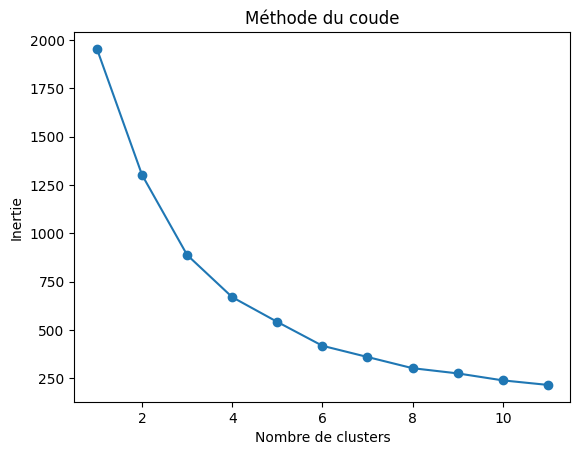

In [95]:
plot_inertia(
    k_range, inertia, title_elbow_plot, xlabel, ylabel
)

In [96]:
n_clusters_kmeans_normal = max_cluster_normal

Le score de silhouette met en évidence une segmentation en 2 groupes bien distincts, tandis que le graphique suggère que l'ajout d'un troisième groupe pourrait apporter une information complémentaire.
Afin de limiter une interprétation trop subjective, le choix du nombre de clusters repose **principalement sur le score de silhouette**.

### **2 - Visualisation des clusters et des centroides**

In [97]:
X_cluster = df_normal_scaled_criterias[columns_pca_normal]

# Use of KMeans
kmeans = KMeans(n_clusters=n_clusters_kmeans_normal, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_cluster)

df_normal_scaled_criterias['KMean_cluster'] = kmeans.labels_

In [98]:
# See the centroids for each kmean clusters
centroids = kmeans.cluster_centers_

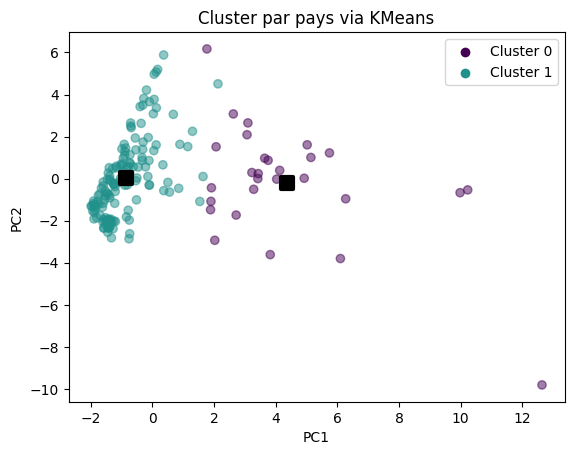

In [99]:
# Plot the cluster
plot_cluster_kmeans_hierarchical(
    "KMeans",
    df_normal_scaled_criterias,
    ["PC1", "PC2", "KMean_cluster"],
    n_clusters_kmeans_normal,
    PLOT_TITLE_CLUSTER_KMEAN,
    "PC1",
    "PC2",
    centroids
)

Grâce à la visualisation des clusters dans l'espace des APC, segmenter en deux groupes distincts est suffisamment claire et explicite.

De manière plus spécifique, le cluster 0 est très dispersé, ce qui créérait des sous-groupes trop petits pour être exploitables.
Le cluster 1, quant à lui, concentre la majorité des pays autour de son centre, avec quelques points légèrement plus éloignés, ce qui justifie un seul cluster.

### **3 - Nombre et pays par cluster**

**1 - Cluster ascendant hierarchique**

In [100]:
# We recreate a dataframe with the standardized values, the countries and the KMean cluster
df_final_normal_scaled_chicken_country = pd.DataFrame(df_normal_scaled_criterias, columns=df_normal_scaled_criterias.columns)
df_final_normal_scaled_chicken_country[columns_pca_normal + ["Pays", "KMean_cluster", "Hierarchical_cluster"]] = df_final_normal_scaled_chicken_country[columns_pca_normal + ["Pays", "KMean_cluster", "Hierarchical_cluster"]]

In [101]:
visualize_cluster_details(df_final_normal_scaled_chicken_country, "Hierarchical_cluster")

 Cluster 1 - Nombre de pays : 168


,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,...,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,PC3,Hierarchical_cluster,KMean_cluster
0,Afghanistan,0.039314,-1.152228,-1.176127,-1.094267,-1.179868,-0.476907,-0.312115,-0.309145,-0.474313,...,-0.185496,-0.221335,0.228962,-0.484401,1.793646,-1.394261,-2.336510,-0.095260,1,1
1,Afrique du Sud,0.230667,1.185100,1.289296,1.099565,1.015886,2.252981,2.314159,0.042733,2.319812,...,1.124074,-0.221335,-0.353441,2.187943,1.083232,5.142249,1.007732,-0.331387,1,0
2,Albanie,-0.269346,0.202745,-0.136906,0.410918,-0.226618,-0.490152,-0.263380,-0.309145,-0.485603,...,-0.217831,-0.221335,0.690795,-0.492180,-0.551425,-1.169055,0.591323,0.016379,1,1
3,Algérie,0.086363,-0.864296,-0.916321,-0.806511,-0.868117,-0.185507,-0.458320,-0.309145,-0.179378,...,-0.007653,-0.221335,-0.872898,-0.199143,1.000586,-0.750663,-1.970751,-0.470967,1,1
4,Allemagne,0.467609,-0.034375,0.171953,-0.152297,-0.026712,1.750978,4.090279,3.298998,1.718652,...,-0.217831,5.301855,0.155020,1.658920,-0.551425,4.924784,0.018797,5.758082,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,Ukraine,-0.024370,-0.034375,0.039325,-0.095729,0.025354,0.276759,-0.333775,-0.309145,0.289132,...,0.267195,-0.221335,-0.799876,0.252082,1.090125,0.555703,-0.637375,-0.959530,1,1
165,Uruguay,0.577932,-0.423930,-0.545691,-0.339215,-0.485660,1.044996,1.106614,-0.303559,1.093501,...,0.412702,-0.221335,-0.361178,1.008015,0.843356,1.887105,-1.477834,0.071228,1,0
166,Vanuatu,-0.038852,-0.728799,-0.721922,-0.720430,-0.729919,-0.226568,-0.046780,-0.309145,-0.217479,...,-0.088491,-0.221335,-0.194105,-0.239339,1.011956,-0.783030,-1.503432,-0.140723,1,1
167,Venezuela (République bolivarienne du),-0.140297,-1.050605,-1.065301,-0.998349,-1.058382,-0.472933,-0.404170,-0.303559,-0.470080,...,-0.185496,-0.221335,-0.450298,-0.480511,0.788616,-1.477833,-1.975383,-0.075947,1,1




 Cluster 2 - Nombre de pays : 1


,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,...,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,PC3,Hierarchical_cluster,KMean_cluster
69,Honduras,12.070725,-1.118353,-1.137973,-1.059835,-1.135516,4.296754,-0.46915,-0.286803,3.632204,...,11.0186,-0.221335,-0.88896,4.033041,5.885117,12.636216,-9.808155,-7.03111,2,0


**Cluster KMeans**

In [102]:
visualize_cluster_details(df_final_normal_scaled_chicken_country, "KMean_cluster")

 Cluster 1 - Nombre de pays : 141


,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,...,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,PC3,Hierarchical_cluster,KMean_cluster
0,Afghanistan,0.039314,-1.152228,-1.176127,-1.094267,-1.179868,-0.476907,-0.312115,-0.309145,-0.474313,...,-0.185496,-0.221335,0.228962,-0.484401,1.793646,-1.394261,-2.336510,-0.095260,1,1
2,Albanie,-0.269346,0.202745,-0.136906,0.410918,-0.226618,-0.490152,-0.263380,-0.309145,-0.485603,...,-0.217831,-0.221335,0.690795,-0.492180,-0.551425,-1.169055,0.591323,0.016379,1,1
3,Algérie,0.086363,-0.864296,-0.916321,-0.806511,-0.868117,-0.185507,-0.458320,-0.309145,-0.179378,...,-0.007653,-0.221335,-0.872898,-0.199143,1.000586,-0.750663,-1.970751,-0.470967,1,1
5,Angola,-0.020543,-0.644113,-0.620180,-0.629431,-0.599433,-0.129876,1.030804,-0.309145,-0.107408,...,-0.185496,-0.155189,0.963704,-0.144685,1.011956,-0.515214,-1.008628,0.653289,1,1
6,Antigua-et-Barbuda,-0.295109,2.709443,1.954252,3.140910,2.199253,-0.543134,-0.431245,-0.309145,-0.544872,...,-0.217831,-0.221335,1.231237,-0.549232,-0.551425,0.059063,4.966164,-1.548712,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,Turquie,-0.293353,-0.559427,-0.538423,-0.565485,-0.528727,-0.548432,-0.447490,-0.309145,-0.547694,...,-0.217831,-0.221335,0.807198,-0.551825,-0.551425,-1.651433,-0.448132,0.410302,1,1
164,Ukraine,-0.024370,-0.034375,0.039325,-0.095729,0.025354,0.276759,-0.333775,-0.309145,0.289132,...,0.267195,-0.221335,-0.799876,0.252082,1.090125,0.555703,-0.637375,-0.959530,1,1
166,Vanuatu,-0.038852,-0.728799,-0.721922,-0.720430,-0.729919,-0.226568,-0.046780,-0.309145,-0.217479,...,-0.088491,-0.221335,-0.194105,-0.239339,1.011956,-0.783030,-1.503432,-0.140723,1,1
167,Venezuela (République bolivarienne du),-0.140297,-1.050605,-1.065301,-0.998349,-1.058382,-0.472933,-0.404170,-0.303559,-0.470080,...,-0.185496,-0.221335,-0.450298,-0.480511,0.788616,-1.477833,-1.975383,-0.075947,1,1


# **Visualisation des clusters**

**Objectif :**  
Identifier le **cluster correspondant le mieux à nos besoins**. Pour ce faire, nous avons appliqué un filtrage basé sur des **importations strictement positives** ainsi qu'un **ratio d’importations nettes supérieur à zéro**
Ces critères permettent d’**affiner la sélection des clusters** en ciblant des pays **principalement dépendants des importations**.

Des critères complémentaires, tels que le **ratio des pertes rapportées à la production**, pourraient également être envisagés. Toutefois, ils ne sont **pas essentiels** dans notre cas d’étude, dans la mesure où un pays **autosuffisant** présente généralement une **faible dépendance aux importations**.


## **Standardisation robuste**

### **1-Ascendant hiérarchique**

In [103]:
PLOT_TITLE_CLUSTER_METRICS = "Répartition des critères par cluster"

In [104]:
# Plot the numeric values for each cluster
grouped_cluster_robust_hierarchical = df_final_robust_scaled_chicken_country.drop(columns_pca_robust + ["Pays", "KMean_cluster"], axis=1).groupby("Hierarchical_cluster").mean(numeric_only=True)

mask_robust_hierarchical = grouped_cluster_robust_hierarchical[CRITERION_IMPORTS_RATIO] > 0
grouped_cluster_robust_hierarchical = grouped_cluster_robust_hierarchical[mask_robust_hierarchical]

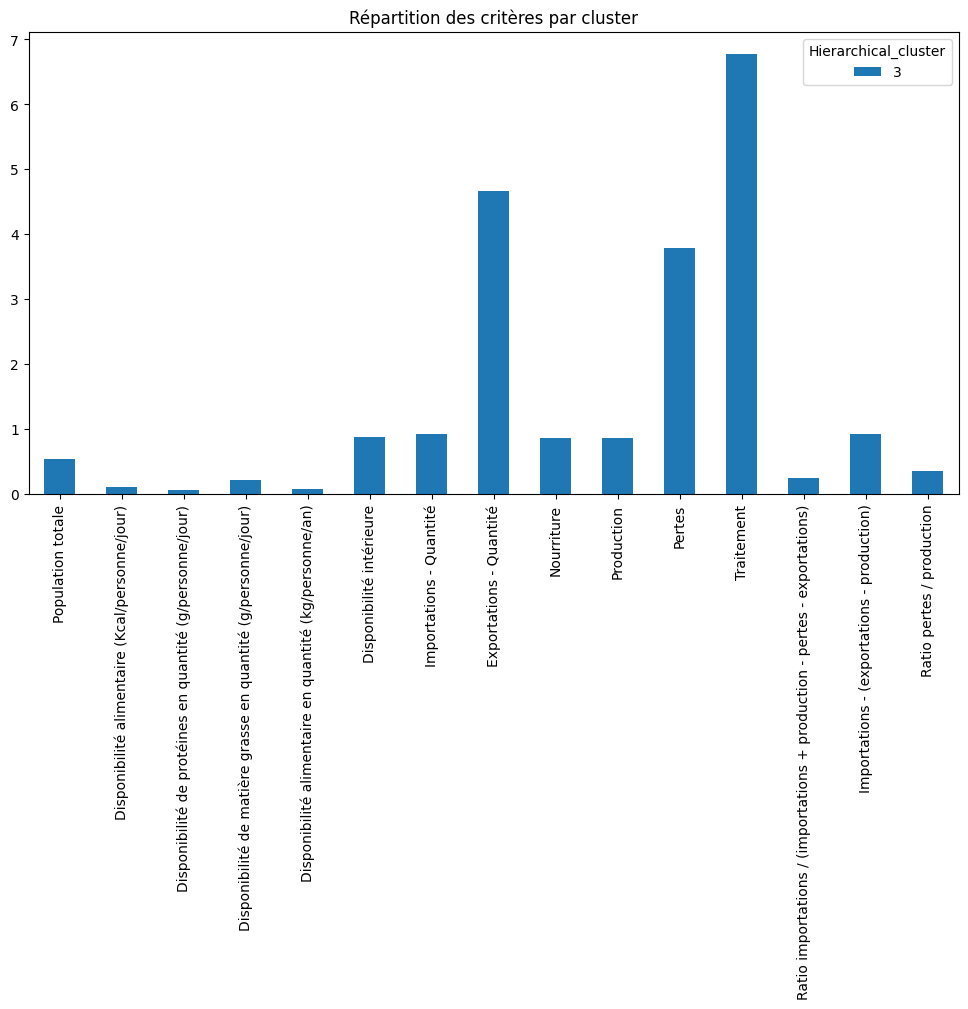

In [105]:
plot_transposed_bar(
    grouped_cluster_robust_hierarchical, (12,6), PLOT_TITLE_CLUSTER_METRICS
)

In [106]:
cluster_normal_hierarchical = grouped_cluster_robust_hierarchical[[CRITERION_IMPORTS_RATIO]].idxmax().iloc[0]

In [107]:
selected_cluster_robust_hierarchical = df_final_robust_scaled_chicken_country[
    df_final_robust_scaled_chicken_country["Hierarchical_cluster"] == cluster_normal_hierarchical
]

cluster_robust_title = f'Cluster {selected_cluster_robust_hierarchical["Hierarchical_cluster"].iloc[0]}'

In [108]:
top_countries_robust_hier = selected_cluster_robust_hierarchical\
.sort_values(CRITERION_IMPORTS_RATIO, ascending=False).head(5)
top_countries_robust_hier

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster,KMean_cluster
31,Chine - RAS de Hong-Kong,-0.089917,1.748503,1.921341,1.743066,1.501006,0.548193,11.609121,55.250000,0.908812,-0.117400,0.0,0.0,4.355632,0.503771,0.0,25.484078,-31.377634,3,0
17,Belgique,0.060956,-0.239521,-0.235976,-0.201460,-0.230533,0.162651,4.195440,54.666667,0.151724,1.109713,0.0,33.0,2.893934,0.132730,0.0,35.085784,-37.770824,3,0
123,Pays-Bas,0.266412,0.071856,0.240854,-0.000973,0.094925,0.825301,7.713355,118.166667,0.770881,2.890287,0.0,104.0,2.568533,0.570136,0.0,102.600127,-87.579181,3,0
47,Émirats arabes unis,-0.009926,0.994012,1.011585,1.071533,1.075538,0.945783,5.433225,7.833333,0.973180,-0.050314,0.0,0.0,1.211755,0.862745,0.0,-8.159211,-5.008541,3,0
93,Luxembourg,-0.336188,0.059880,0.083537,0.104136,0.010171,-0.262048,-0.065147,0.083333,-0.255939,-0.184486,0.0,0.0,1.185578,-0.274510,0.0,-14.283916,-0.712502,3,0


In [109]:
print("Standardisation robuste - cluster ascendance hiérarchique")
print("---")
for i, country in enumerate(top_countries_robust_hier["Pays"]):
  print(f"- Position {i+1} -> {country}")

Standardisation robuste - cluster ascendance hiérarchique
---
- Position 1 -> Chine - RAS de Hong-Kong
- Position 2 -> Belgique
- Position 3 -> Pays-Bas
- Position 4 -> Émirats arabes unis
- Position 5 -> Luxembourg


In [110]:
PLOT_TITLE_TOP_COUNTRIES_IMPORT = "Top pays les plus dépendants des importations en volaille"

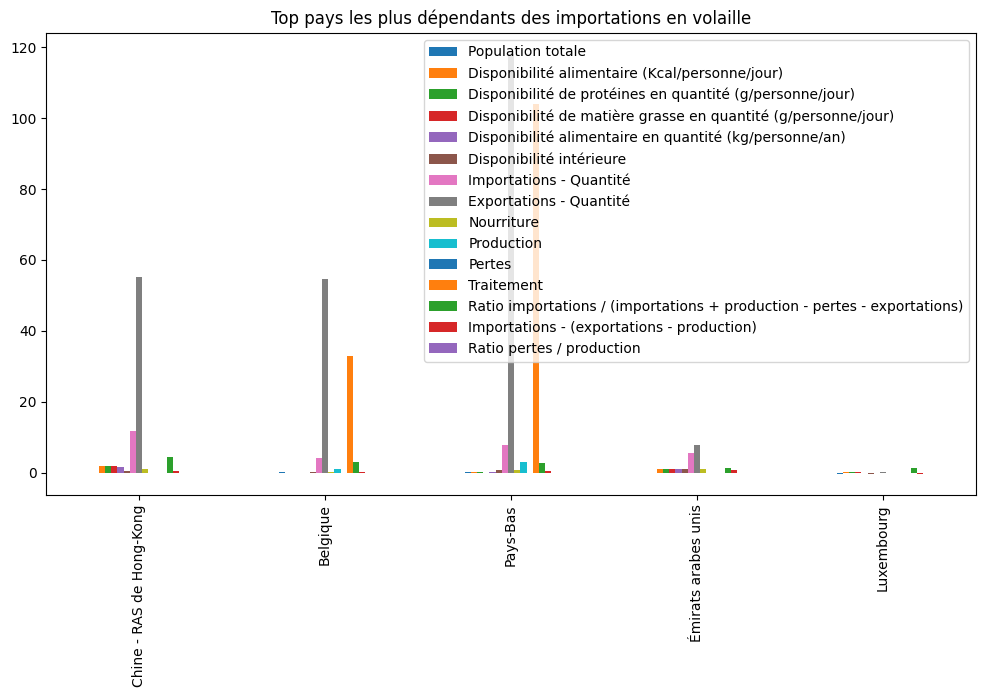

In [111]:
top_countries_robust_hier.drop(columns_pca_robust + ["KMean_cluster", "Hierarchical_cluster"], axis=1)\
.plot(x="Pays",
                                       kind="bar",
                                       figsize=(12,6),
                                       title=f'{PLOT_TITLE_TOP_COUNTRIES_IMPORT}',
                                       rot=90)
plt.xlabel("")
plt.show()

### **2-KMeans**

In [112]:
# Plot the numeric values for each cluster
grouped_cluster_robust_kmean = df_final_robust_scaled_chicken_country.drop(columns_pca_robust + ["Pays", "Hierarchical_cluster"], axis=1).groupby("KMean_cluster").mean(numeric_only=True)

mask_robust_kmean = grouped_cluster_robust_kmean[CRITERION_IMPORTS_RATIO] > 0

grouped_cluster_robust_kmean = grouped_cluster_robust_kmean[mask_robust_kmean]

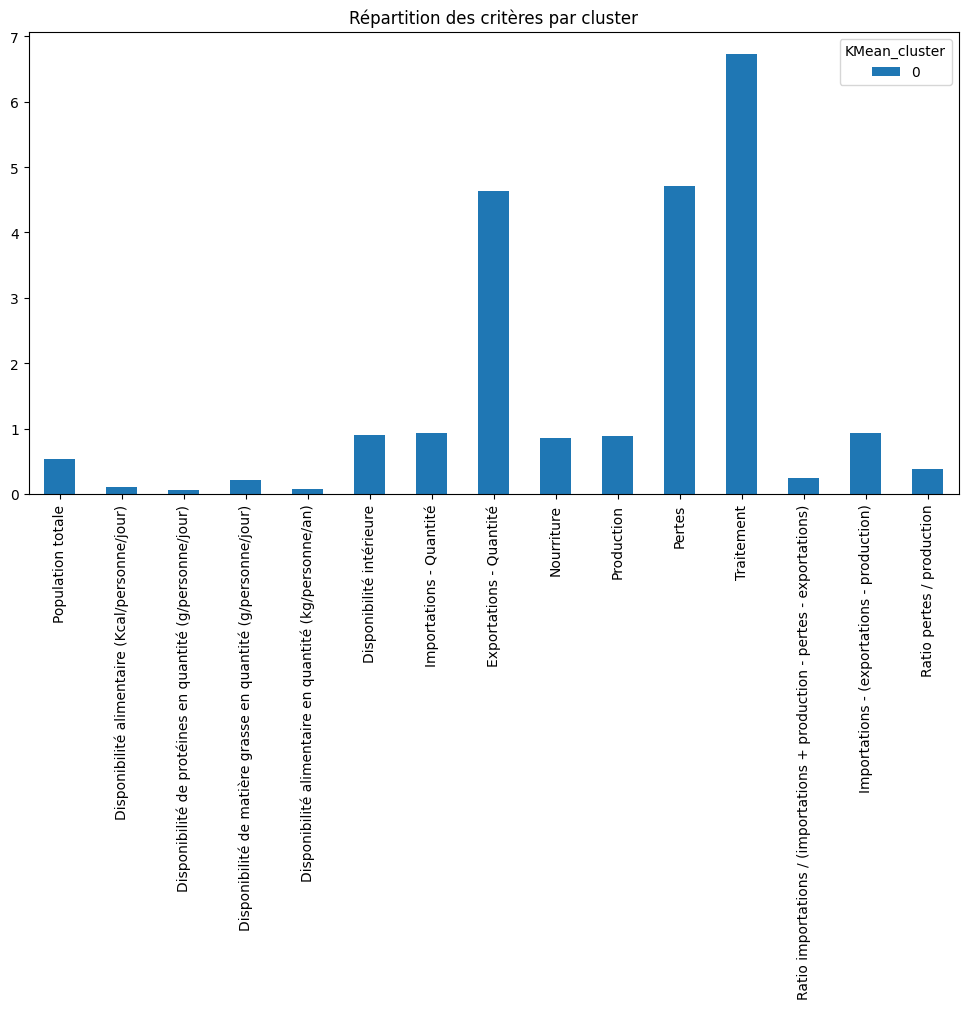

In [113]:
plot_transposed_bar(
    grouped_cluster_robust_kmean, (12,6), PLOT_TITLE_CLUSTER_METRICS
)

In [114]:
cluster_robust_Kmean = grouped_cluster_robust_kmean[[CRITERION_IMPORTS_RATIO]].idxmax().iloc[0]

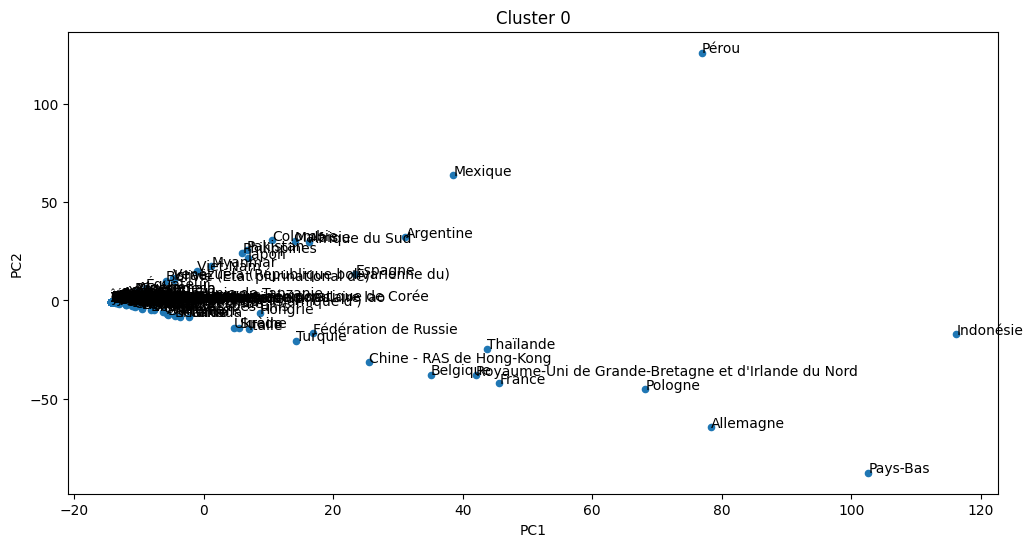

In [115]:
# Select the countries from the clu
selected_cluster_robust_kmean = df_final_robust_scaled_chicken_country[
    df_final_robust_scaled_chicken_country['KMean_cluster'] == cluster_robust_Kmean
]
cluster_robust_title = f'Cluster {selected_cluster_robust_kmean["KMean_cluster"].iloc[0]}'


selected_cluster_robust_kmean.plot(x="PC1", y="PC2", kind="scatter", figsize=(12,6), title=cluster_robust_title)
for index, row in selected_cluster_robust_kmean.iterrows():
    plt.annotate(row['Pays'], (row['PC1'], row['PC2']))
plt.show()

In [116]:
top_countries_robust_kmeans = selected_cluster_robust_kmean\
.sort_values(
    CRITERION_IMPORTS_RATIO, ascending=False).head(5)

top_countries_robust_kmeans

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production,PC1,PC2,Hierarchical_cluster,KMean_cluster
31,Chine - RAS de Hong-Kong,-0.089917,1.748503,1.921341,1.743066,1.501006,0.548193,11.609121,55.250000,0.908812,-0.117400,0.0,0.0,4.355632,0.503771,0.0,25.484078,-31.377634,3,0
17,Belgique,0.060956,-0.239521,-0.235976,-0.201460,-0.230533,0.162651,4.195440,54.666667,0.151724,1.109713,0.0,33.0,2.893934,0.132730,0.0,35.085784,-37.770824,3,0
123,Pays-Bas,0.266412,0.071856,0.240854,-0.000973,0.094925,0.825301,7.713355,118.166667,0.770881,2.890287,0.0,104.0,2.568533,0.570136,0.0,102.600127,-87.579181,3,0
47,Émirats arabes unis,-0.009926,0.994012,1.011585,1.071533,1.075538,0.945783,5.433225,7.833333,0.973180,-0.050314,0.0,0.0,1.211755,0.862745,0.0,-8.159211,-5.008541,3,0
93,Luxembourg,-0.336188,0.059880,0.083537,0.104136,0.010171,-0.262048,-0.065147,0.083333,-0.255939,-0.184486,0.0,0.0,1.185578,-0.274510,0.0,-14.283916,-0.712502,3,0


In [117]:
print("Standardisation robuste - cluster KMeans")
print("---")
for i, country in enumerate(top_countries_robust_kmeans["Pays"]):
  print(f"- Position {i+1} -> {country}")

Standardisation robuste - cluster KMeans
---
- Position 1 -> Chine - RAS de Hong-Kong
- Position 2 -> Belgique
- Position 3 -> Pays-Bas
- Position 4 -> Émirats arabes unis
- Position 5 -> Luxembourg


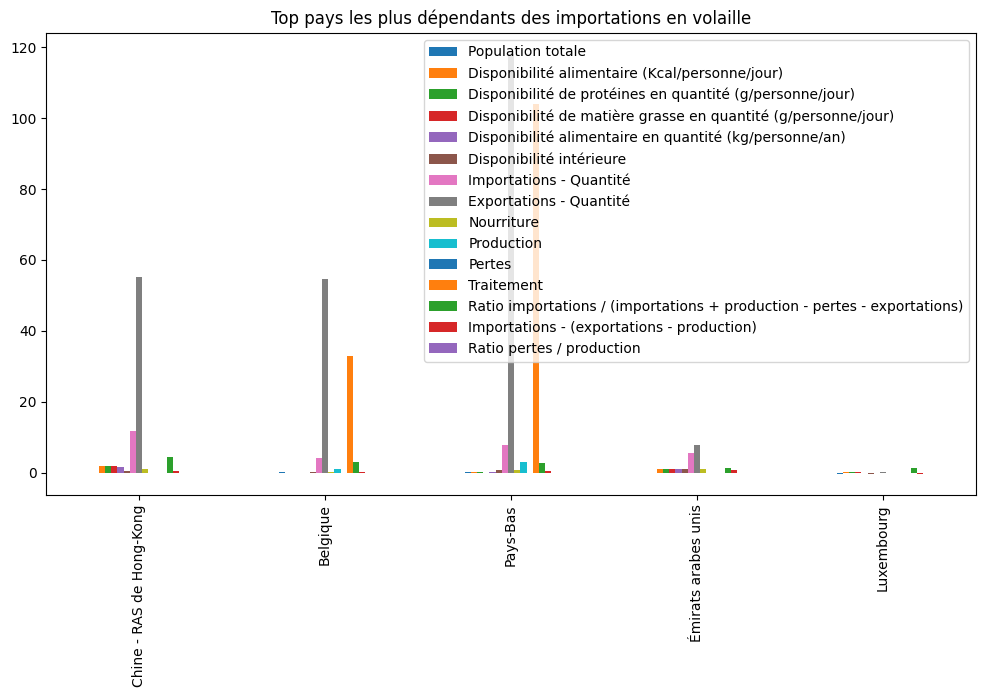

In [118]:
top_countries_robust_kmeans.drop(columns_pca_robust + ["KMean_cluster", "Hierarchical_cluster"], axis=1)\
.plot(x="Pays", kind="bar", figsize=(12,6), title=f'{PLOT_TITLE_TOP_COUNTRIES_IMPORT}', rot=90)
plt.xlabel("")
plt.show()

In [119]:
print("Standardisation robuste - cluster ascendance hiérarchique")
print("---")
for i, country in enumerate(top_countries_robust_hier["Pays"]):
  print(f"- Position {i+1} -> {country}")

Standardisation robuste - cluster ascendance hiérarchique
---
- Position 1 -> Chine - RAS de Hong-Kong
- Position 2 -> Belgique
- Position 3 -> Pays-Bas
- Position 4 -> Émirats arabes unis
- Position 5 -> Luxembourg


In [120]:
robust_ranking_countries = pd.DataFrame({
    "Position": [i+1 for i in range(len(top_countries_robust_hier))],
    "classification": top_countries_robust_hier["Pays"].values,
    "kmeans": top_countries_robust_kmeans["Pays"].values
})
robust_ranking_countries

,Position,classification,kmeans
0,1,Chine - RAS de Hong-Kong,Chine - RAS de Hong-Kong
1,2,Belgique,Belgique
2,3,Pays-Bas,Pays-Bas
3,4,Émirats arabes unis,Émirats arabes unis
4,5,Luxembourg,Luxembourg


Après comparaison des deux techniques de segmentation, sans exclure aucun pays, le top 5 des pays les plus dépendants des importations reste identique.

De manière générale, Hong Kong apparaît comme le pays le plus impacté par les importations, ce qui en fait une zone cible pertinente pour le produit de l'entreprise. Cette dépendance doit toutefois être nuancée : le volume des exportations est près de six fois supérieur aux importations, et la répartition de cette denrée au sein de la population reste relativement homogène.

Plusieurs interrogations émergent alors :
s'agit-il d'une volonté de se positionner sur des produits de qualité, voire d'exception ?
ou bien d'un rééquilibrage lié à une politique d'exportation particulièrement agressive ?

Dans les deux cas, cette zone constitue une cible légitime. L'entreprise pourrait ainsi se différencier en misant sur la qualité du produit, notamment à travers un label biologique, et en valorisant le savoir-faire français.

## **Standardisation normale**

### **1-Ascendant hiérarchique**

In [121]:
# Plot the numeric values for each cluster
grouped_cluster_normal_hierarchical = df_final_normal_scaled_chicken_country.drop(columns_pca_normal + ["Pays", "KMean_cluster"], axis=1).groupby("Hierarchical_cluster").mean(numeric_only=True)

mask_normal_hierarchical = grouped_cluster_normal_hierarchical[CRITERION_IMPORTS_RATIO] > 0
grouped_cluster_normal_hierarchical = grouped_cluster_normal_hierarchical[mask_normal_hierarchical]

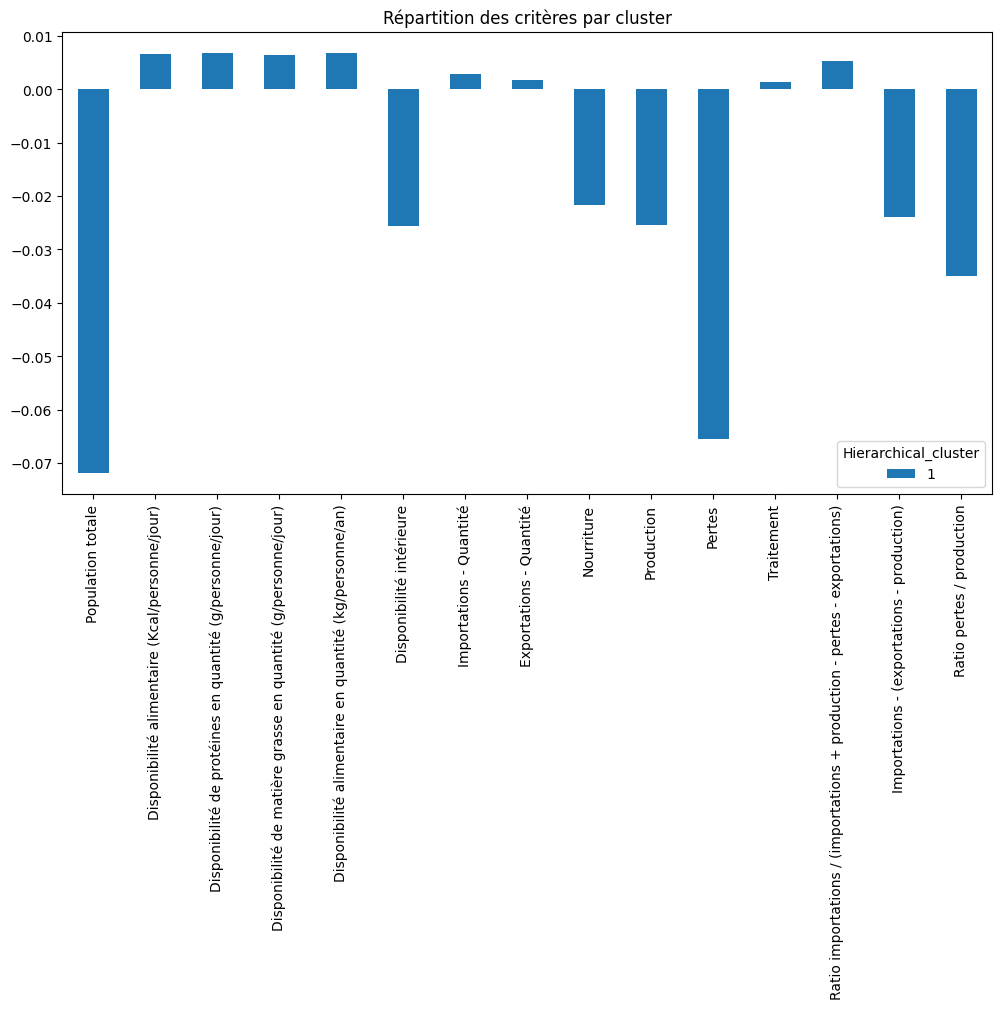

In [122]:
plot_transposed_bar(
    grouped_cluster_normal_hierarchical, (12,6), PLOT_TITLE_CLUSTER_METRICS
)

In [123]:
cluster_normal_hierarchical = grouped_cluster_normal_hierarchical[[CRITERION_IMPORTS, CRITERION_IMPORTS_RATIO]].idxmax().iloc[0]

In [124]:
selected_cluster_normal_hierarchical = df_final_normal_scaled_chicken_country[
    df_final_normal_scaled_chicken_country['Hierarchical_cluster'] == cluster_normal_hierarchical
]

cluster_normal_title = f'Cluster {selected_cluster_normal_hierarchical["Hierarchical_cluster"].iloc[0]}'

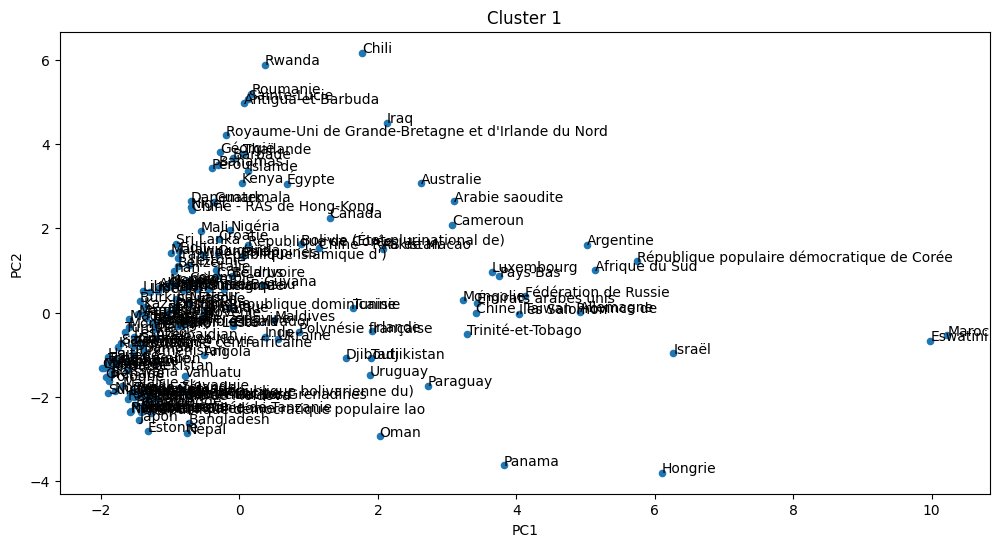

In [125]:
# Select the countries from the clu
selected_cluster_normal_hierarchical = df_final_normal_scaled_chicken_country[
    df_final_normal_scaled_chicken_country["Hierarchical_cluster"] == cluster_normal_hierarchical
]
cluster_robust_title = f'Cluster {selected_cluster_normal_hierarchical["Hierarchical_cluster"].iloc[0]}'


selected_cluster_normal_hierarchical.plot(x="PC1", y="PC2", kind="scatter", figsize=(12,6), title=cluster_normal_title)
for index, row in selected_cluster_normal_hierarchical.iterrows():
    plt.annotate(row['Pays'], (row['PC1'], row['PC2']))
plt.show()

In [126]:
top_countries_normal_hier = selected_cluster_normal_hierarchical.drop(columns_pca_normal + ["KMean_cluster", "Hierarchical_cluster"], axis=1)\
.sort_values(CRITERION_IMPORTS_RATIO, ascending=False).head(5)

top_countries_normal_hier

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
30,Chili,-0.228495,2.319889,2.770003,1.948076,2.161328,-0.181533,4.442254,3.393950,-0.000159,-0.508848,-0.217831,-0.221335,6.286482,-0.210813,-0.551425
17,Belgique,-0.190495,-0.491679,-0.443949,-0.508918,-0.465091,-0.351075,1.361119,3.354852,-0.348719,0.086374,-0.217831,0.870074,4.053292,-0.370298,-0.551425
120,Pakistan,-0.138747,-0.051313,0.266427,-0.255594,0.028568,-0.059675,2.823169,7.610897,-0.063661,0.950056,-0.217831,3.218257,3.556142,-0.182287,-0.551425
45,Égypte,-0.208348,1.252848,1.414656,1.099565,1.515972,-0.006693,1.875544,0.215879,0.029476,-0.476308,-0.217831,-0.221335,1.483250,-0.056514,-0.551425
90,Liban,-0.290522,-0.068250,0.032058,-0.122783,-0.099989,-0.537836,-0.409585,-0.303559,-0.536405,-0.541389,-0.217831,-0.221335,1.443257,-0.545342,-0.551425


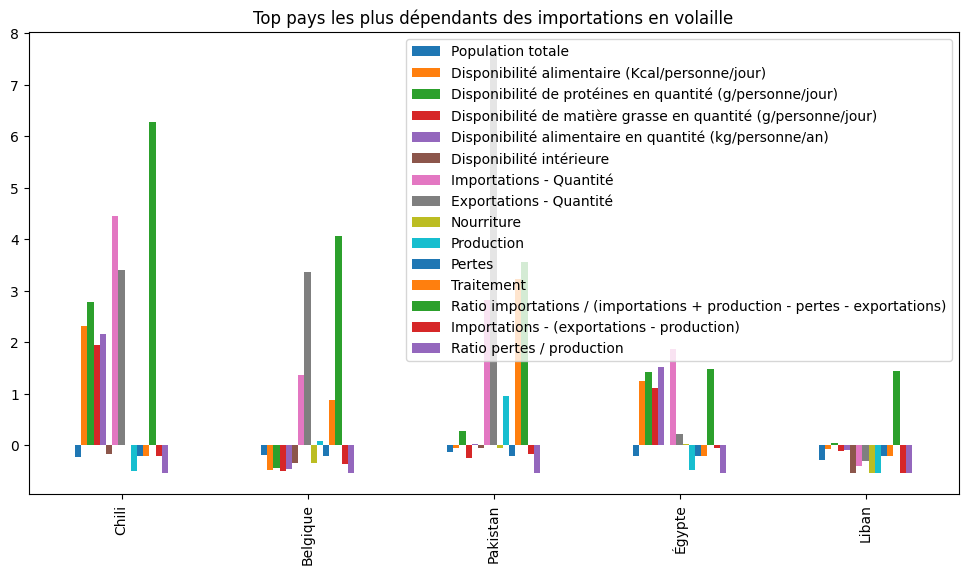

In [127]:
top_countries_normal_hier.plot(x="Pays",
      kind="bar",
      figsize=(12,6),
      title=f'{PLOT_TITLE_TOP_COUNTRIES_IMPORT}',
      rot=90)
plt.xlabel("")
plt.show()

In [128]:
print("Standardisation normale - cluster Ascendant hierarchique")
print("---")
for i, country in enumerate(top_countries_normal_hier["Pays"]):
  print(f"- Position {i+1} -> {country}")

Standardisation normale - cluster Ascendant hierarchique
---
- Position 1 -> Chili
- Position 2 -> Belgique
- Position 3 -> Pakistan
- Position 4 -> Égypte
- Position 5 -> Liban


### **2-KMeans**

In [129]:
# Plot the numeric values for each cluster
grouped_cluster_normal_kmean = df_final_normal_scaled_chicken_country.drop(columns_pca_normal + ["Pays", "Hierarchical_cluster"], axis=1).groupby("KMean_cluster").mean(numeric_only=True)

mask_normal_kmean = grouped_cluster_normal_kmean[CRITERION_IMPORTS_RATIO] > 0

grouped_cluster_normal_kmean = grouped_cluster_normal_kmean[mask_normal_kmean]

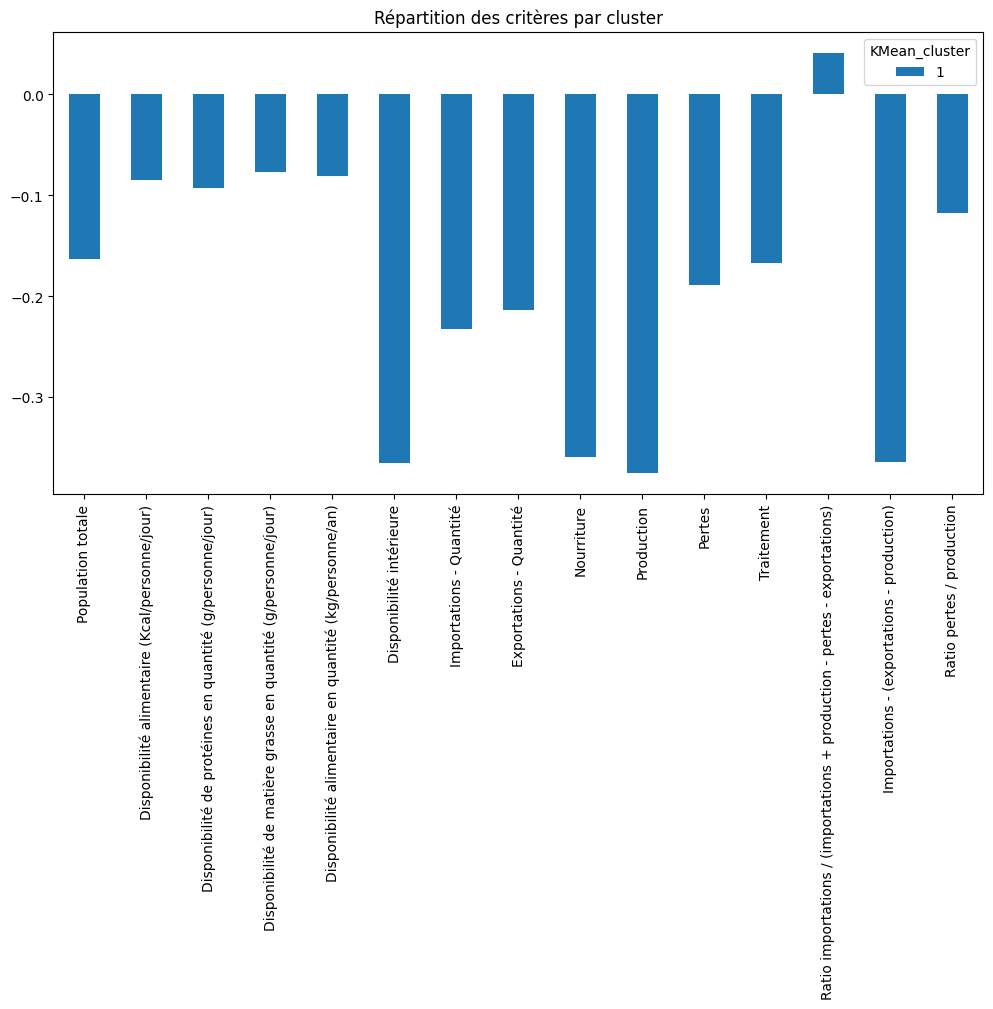

In [130]:
plot_transposed_bar(
    grouped_cluster_normal_kmean, (12,6), PLOT_TITLE_CLUSTER_METRICS
)

In [131]:
cluster_normal_Kmean = grouped_cluster_normal_kmean[[CRITERION_IMPORTS, CRITERION_IMPORTS_RATIO]].idxmax().iloc[0]

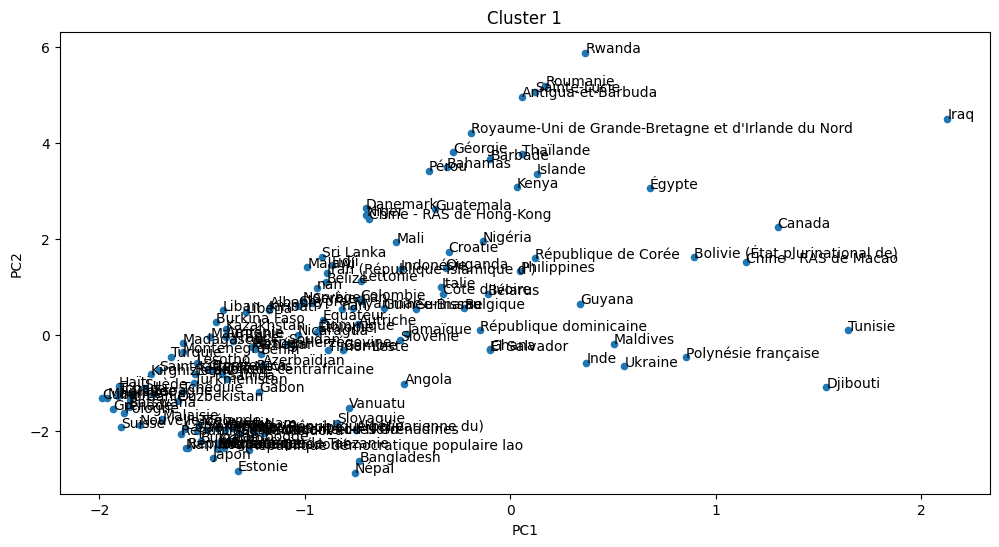

In [132]:
# Select the countries from the clu
selected_cluster_normal_kmean = df_final_normal_scaled_chicken_country[
    df_final_normal_scaled_chicken_country['KMean_cluster'] == cluster_normal_Kmean
]
cluster_normal_title = f'Cluster {selected_cluster_normal_kmean["KMean_cluster"].iloc[0]}'


selected_cluster_normal_kmean.plot(x="PC1", y="PC2", kind="scatter", figsize=(12,6), title=cluster_normal_title)
for index, row in selected_cluster_normal_kmean.iterrows():
    plt.annotate(row['Pays'], (row['PC1'], row['PC2']))
plt.show()

In [133]:
top_countries_normal_kmeans = selected_cluster_normal_kmean\
.sort_values(CRITERION_IMPORTS_RATIO, ascending=False)\
.drop(columns_pca_normal + ["KMean_cluster", "Hierarchical_cluster"], axis=1).head(5)

top_countries_normal_kmeans

,Pays,Population totale,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Nourriture,Production,Pertes,Traitement,Ratio importations / (importations + production - pertes - exportations),Importations - (exportations - production),Ratio pertes / production
17,Belgique,-0.190495,-0.491679,-0.443949,-0.508918,-0.465091,-0.351075,1.361119,3.354852,-0.348719,0.086374,-0.217831,0.870074,4.053292,-0.370298,-0.551425
45,Égypte,-0.208348,1.252848,1.414656,1.099565,1.515972,-0.006693,1.875544,0.215879,0.029476,-0.476308,-0.217831,-0.221335,1.483250,-0.056514,-0.551425
90,Liban,-0.290522,-0.068250,0.032058,-0.122783,-0.099989,-0.537836,-0.409585,-0.303559,-0.536405,-0.541389,-0.217831,-0.221335,1.443257,-0.545342,-0.551425
114,Norvège,-0.252887,-0.000501,0.066577,-0.049000,0.112130,-0.401408,0.213140,-0.219779,-0.409399,-0.531898,-0.217831,-0.221335,1.394329,-0.406603,-0.551425
106,Monténégro,-0.273795,-0.559427,-0.502087,-0.590079,-0.537083,-0.515319,-0.312115,-0.242120,-0.512415,-0.526474,-0.217831,-0.221335,1.306958,-0.522003,-0.551425


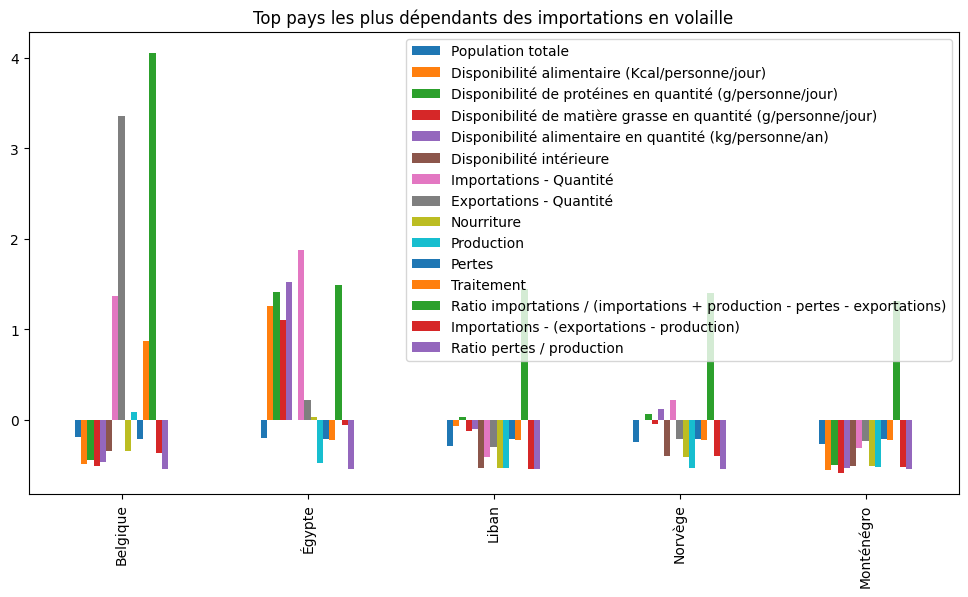

In [134]:
top_countries_normal_kmeans.plot(x="Pays", kind="bar", figsize=(12,6), title=f'{PLOT_TITLE_TOP_COUNTRIES_IMPORT}', rot=90)
plt.xlabel("")
plt.show()

In [135]:
print("Standardisation normale - cluster KMeans")
print("---")
for i, country in enumerate(top_countries_normal_kmeans["Pays"]):
  print(f"- Position {i+1} -> {country}")

Standardisation normale - cluster KMeans
---
- Position 1 -> Belgique
- Position 2 -> Égypte
- Position 3 -> Liban
- Position 4 -> Norvège
- Position 5 -> Monténégro


In [136]:
normal_ranking_countries = pd.DataFrame({
    "Position": [i+1 for i in range(len(top_countries_normal_hier))],
    "classification": top_countries_normal_hier["Pays"].values,
    "kmeans": top_countries_normal_kmeans["Pays"].values
})
normal_ranking_countries

,Position,classification,kmeans
0,1,Chili,Belgique
1,2,Belgique,Égypte
2,3,Pakistan,Liban
3,4,Égypte,Norvège
4,5,Liban,Monténégro


Le Chili et la Belgique sont les deux pays où la part des importations est suffisamment importante pour influencer la politique agricole et les rendre dépendants des importations.

Le Chili exporte presque autant de poulet qu'il n'en importe, avec une production légèrement inférieure à la moyenne du cluster. Mais la répartition des denrées est largement supérieur à la moyenne des autres pays, ce qui fait une meilleure accessibilité au poulet pour l'ensemble de la population.

La Belgique produit plus que le Chili mais la redistribution du poulet est en dessous de la moyenne des autres pays.

En combinant ces différents critères, le Chili apparait de manière objective comme le pays à cibler en priorité pour l'entreprise.